# 6CS012 Final Portfolio Project 2026
## Part II: Vision Tasks — Traffic Sign Recognition
### Image Classification with Convolutional Neural Networks

| | |
|---|---|
| **Dataset** | Traffic Sign Recognition (4-class) |
| **Classes** | Caution · Instructions · No Passing · OverSpeed |
| **Train Images** | 15,895 · **Val** · **Test** 627 |
| **Framework** | TensorFlow / Keras |
| **Hardware** | Google Colab GPU / TPU |

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Section 0 — Reproducibility & Environment Setup

In [2]:
# ── Reproducibility (set BEFORE any imports that touch randomness) ────────────
import os, random
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)

# ── Standard imports ──────────────────────────────────────────────────────────
import time, warnings, shutil, struct
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from pathlib import Path
from PIL import Image, UnidentifiedImageError
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'DejaVu Sans'})

# ── Sklearn metrics ───────────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

# ── Keras ─────────────────────────────────────────────────────────────────────
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, mixed_precision
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

# ── GPU Detection ─────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
tpus = tf.config.list_physical_devices('TPU')
print(f'TensorFlow : {tf.__version__}')
print(f'GPUs found : {gpus}')
print(f'TPUs found : {tpus}')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print('  --> Memory growth enabled on all GPUs')
print(f'Seed fixed : {SEED}')
print('Environment ready.')

TensorFlow : 2.20.0
GPUs found : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TPUs found : []
  --> Memory growth enabled on all GPUs
Seed fixed : 42
Environment ready.


---
## Section 1 — Configuration & Paths

In [3]:
# ═══════════════════════════════════════════════════════════════════
#  CONFIGURE THESE THREE PATHS TO MATCH YOUR FOLDER STRUCTURE
#  ─────────────────────────────────────────────────────────────────
#  Google Colab example:
#    from google.colab import drive
#    drive.mount('/content/drive')
#    TRAIN_DIR = '/content/drive/MyDrive/TrafficSigns/Train'
#    VAL_DIR   = '/content/drive/MyDrive/TrafficSigns/Val'
#    TEST_DIR  = '/content/drive/MyDrive/TrafficSigns/Test'
# ═══════════════════════════════════════════════════════════════════

TRAIN_DIR = '/content/drive/MyDrive/AI ASSESSMENT/Traffic_Sign/Train'
VAL_DIR   = '/content/drive/MyDrive/AI ASSESSMENT/Traffic_Sign/Val'      # your dedicated validation folder
TEST_DIR  = '/content/drive/MyDrive/AI ASSESSMENT/Traffic_Sign/Test'

# ── Image & training hyper-parameters ────────────────────────────
IMG_SIZE    = 64          # Part A: 64x64
TL_SIZE     = 96          # Part B: 96x96 (change to 224 if VRAM allows)
BATCH_SIZE  = 32
NUM_CLASSES = 4
CLASS_NAMES = ['Caution', 'Instructions', 'No Passing', 'OverSpeed']

print(f'Train dir  : {TRAIN_DIR}')
print(f'Val dir    : {VAL_DIR}')
print(f'Test dir   : {TEST_DIR}')
print(f'IMG_SIZE   : {IMG_SIZE}')
print(f'BATCH_SIZE : {BATCH_SIZE}')
print(f'Classes    : {CLASS_NAMES}')

Train dir  : /content/drive/MyDrive/AI ASSESSMENT/Traffic_Sign/Train
Val dir    : /content/drive/MyDrive/AI ASSESSMENT/Traffic_Sign/Val
Test dir   : /content/drive/MyDrive/AI ASSESSMENT/Traffic_Sign/Test
IMG_SIZE   : 64
BATCH_SIZE : 32
Classes    : ['Caution', 'Instructions', 'No Passing', 'OverSpeed']


---
## Section 2 — Dataset Diagnostics & Quality Checks

### 2.1 Image Count per Split

In [4]:
def count_images(root):
    counts = {}
    for cls in sorted(os.listdir(root)):
        p = os.path.join(root, cls)
        if os.path.isdir(p):
            imgs = [f for f in os.listdir(p)
                    if f.lower().endswith(('.jpg','.jpeg','.png','.bmp','.ppm'))]
            counts[cls] = len(imgs)
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

# ── Pretty print ──────────────────────────────────────────────────
print(f'{'Class':<22} {'Train':>8} {'Val':>8} {'Test':>8}')
print('─' * 50)
for cls in train_counts:
    print(f'{cls:<22} {train_counts[cls]:>8} {val_counts.get(cls,0):>8} {test_counts.get(cls,0):>8}')
print('─' * 50)
print(f'{'TOTAL':<22} {sum(train_counts.values()):>8} {sum(val_counts.values()):>8} {sum(test_counts.values()):>8}')

Class                     Train      Val     Test
──────────────────────────────────────────────────
Caution                     818        0      108
Instructions                755        0      159
No Passing                  877        0       60
OverSpeed                   713        0      300
──────────────────────────────────────────────────
TOTAL                      3163     2182      627


### 2.2 Data Quality Check — Corrupted & Unreadable Images

In [5]:
def check_image_quality(root, split_name):
    bad, dims = [], []
    for cls in sorted(os.listdir(root)):
        cls_path = os.path.join(root, cls)
        if not os.path.isdir(cls_path): continue
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()
                with Image.open(fpath) as img:
                    dims.append(img.size)
            except (UnidentifiedImageError, Exception) as e:
                bad.append((fpath, str(e)))
    print(f'\n[{split_name}] Corrupted files : {len(bad)}')
    if bad:
        for b in bad[:5]: print(f'  {b[0]}')
    if dims:
        ws = [d[0] for d in dims]; hs = [d[1] for d in dims]
        print(f'[{split_name}] Width  range  : {min(ws)} – {max(ws)} px')
        print(f'[{split_name}] Height range  : {min(hs)} – {max(hs)} px')
        print(f'[{split_name}] Unique sizes  : {len(set(dims))} different shapes')
    return bad, dims

bad_train, dims_train = check_image_quality(TRAIN_DIR, 'Train')
bad_val,   dims_val   = check_image_quality(VAL_DIR,   'Val')
bad_test,  dims_test  = check_image_quality(TEST_DIR,  'Test')


[Train] Corrupted files : 0
[Train] Width  range  : 25 – 205 px
[Train] Height range  : 25 – 192 px
[Train] Unique sizes  : 922 different shapes

[Val] Corrupted files : 0
[Val] Width  range  : 224 – 224 px
[Val] Height range  : 224 – 224 px
[Val] Unique sizes  : 1 different shapes

[Test] Corrupted files : 0
[Test] Width  range  : 26 – 182 px
[Test] Height range  : 25 – 181 px
[Test] Unique sizes  : 337 different shapes


### 2.3 Class Distribution Visualisation

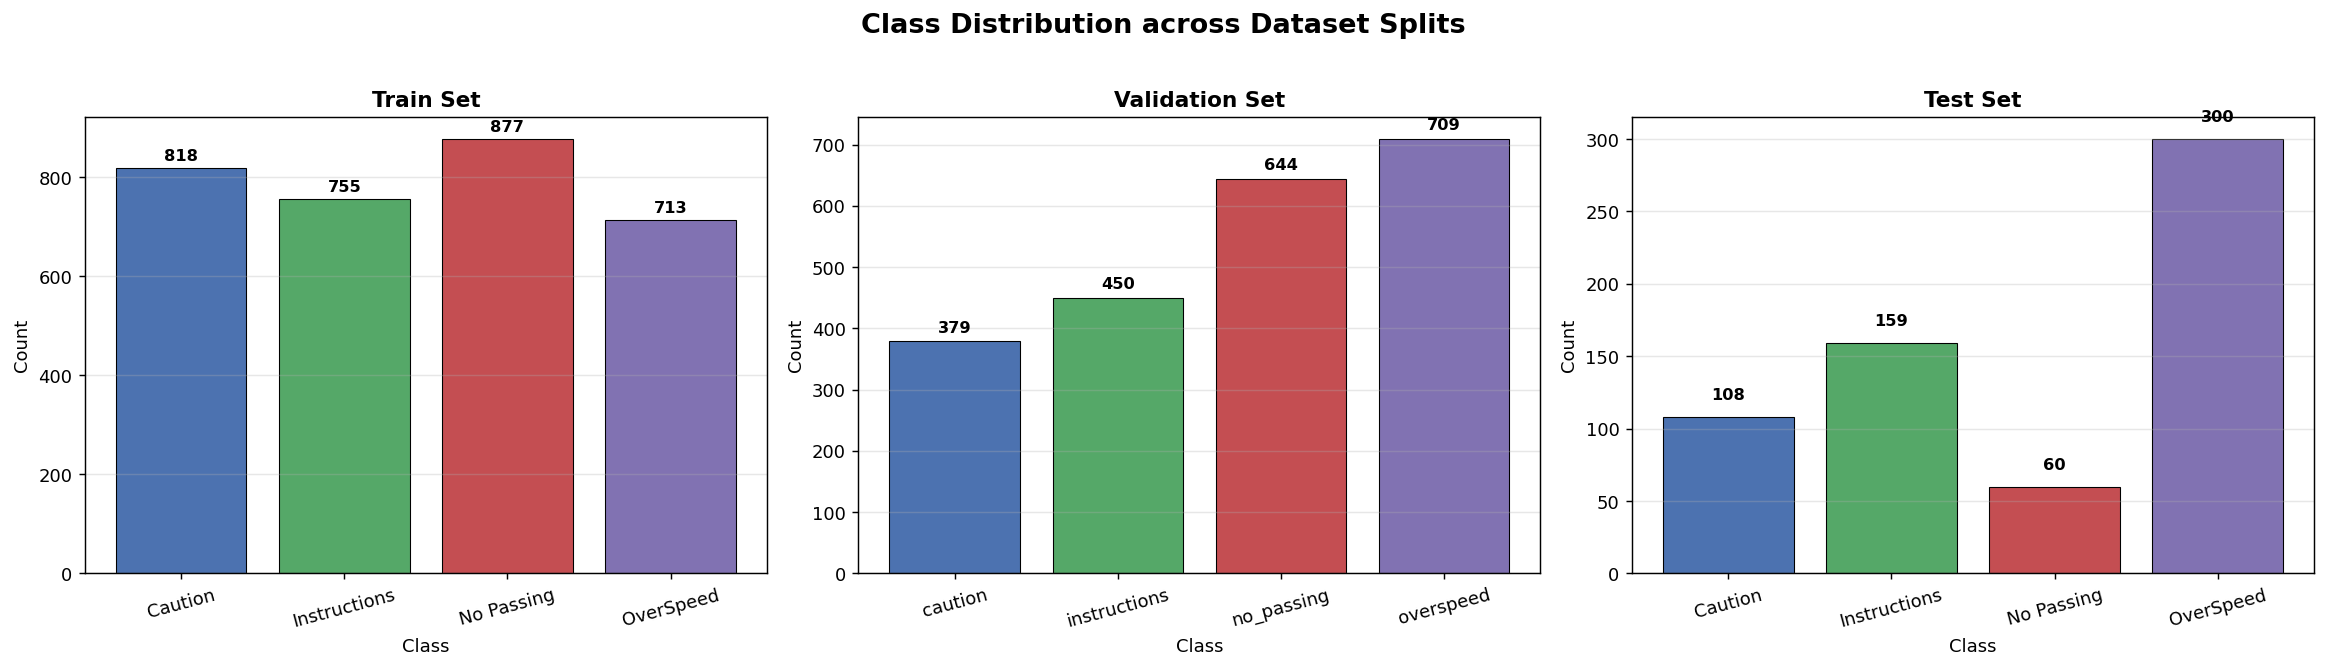


Imbalance ratio (max/min) = 1.23x
Class weights will be applied to compensate for imbalance.


In [6]:
COLORS = ['#4C72B0','#55A868','#C44E52','#8172B2']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Class Distribution across Dataset Splits', fontsize=15, fontweight='bold', y=1.02)

for ax, (split_name, counts) in zip(axes, [
        ('Train', train_counts), ('Validation', val_counts), ('Test', test_counts)]):
    classes = list(counts.keys())
    vals    = list(counts.values())
    bars = ax.bar(classes, vals, color=COLORS, edgecolor='black', linewidth=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                str(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'{split_name} Set', fontsize=12, fontweight='bold')
    ax.set_xlabel('Class'); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Imbalance ratio ───────────────────────────────────────────────
vals = list(train_counts.values())
print(f'\nImbalance ratio (max/min) = {max(vals)/min(vals):.2f}x')
print('Class weights will be applied to compensate for imbalance.')

### 2.4 Sample Images per Class

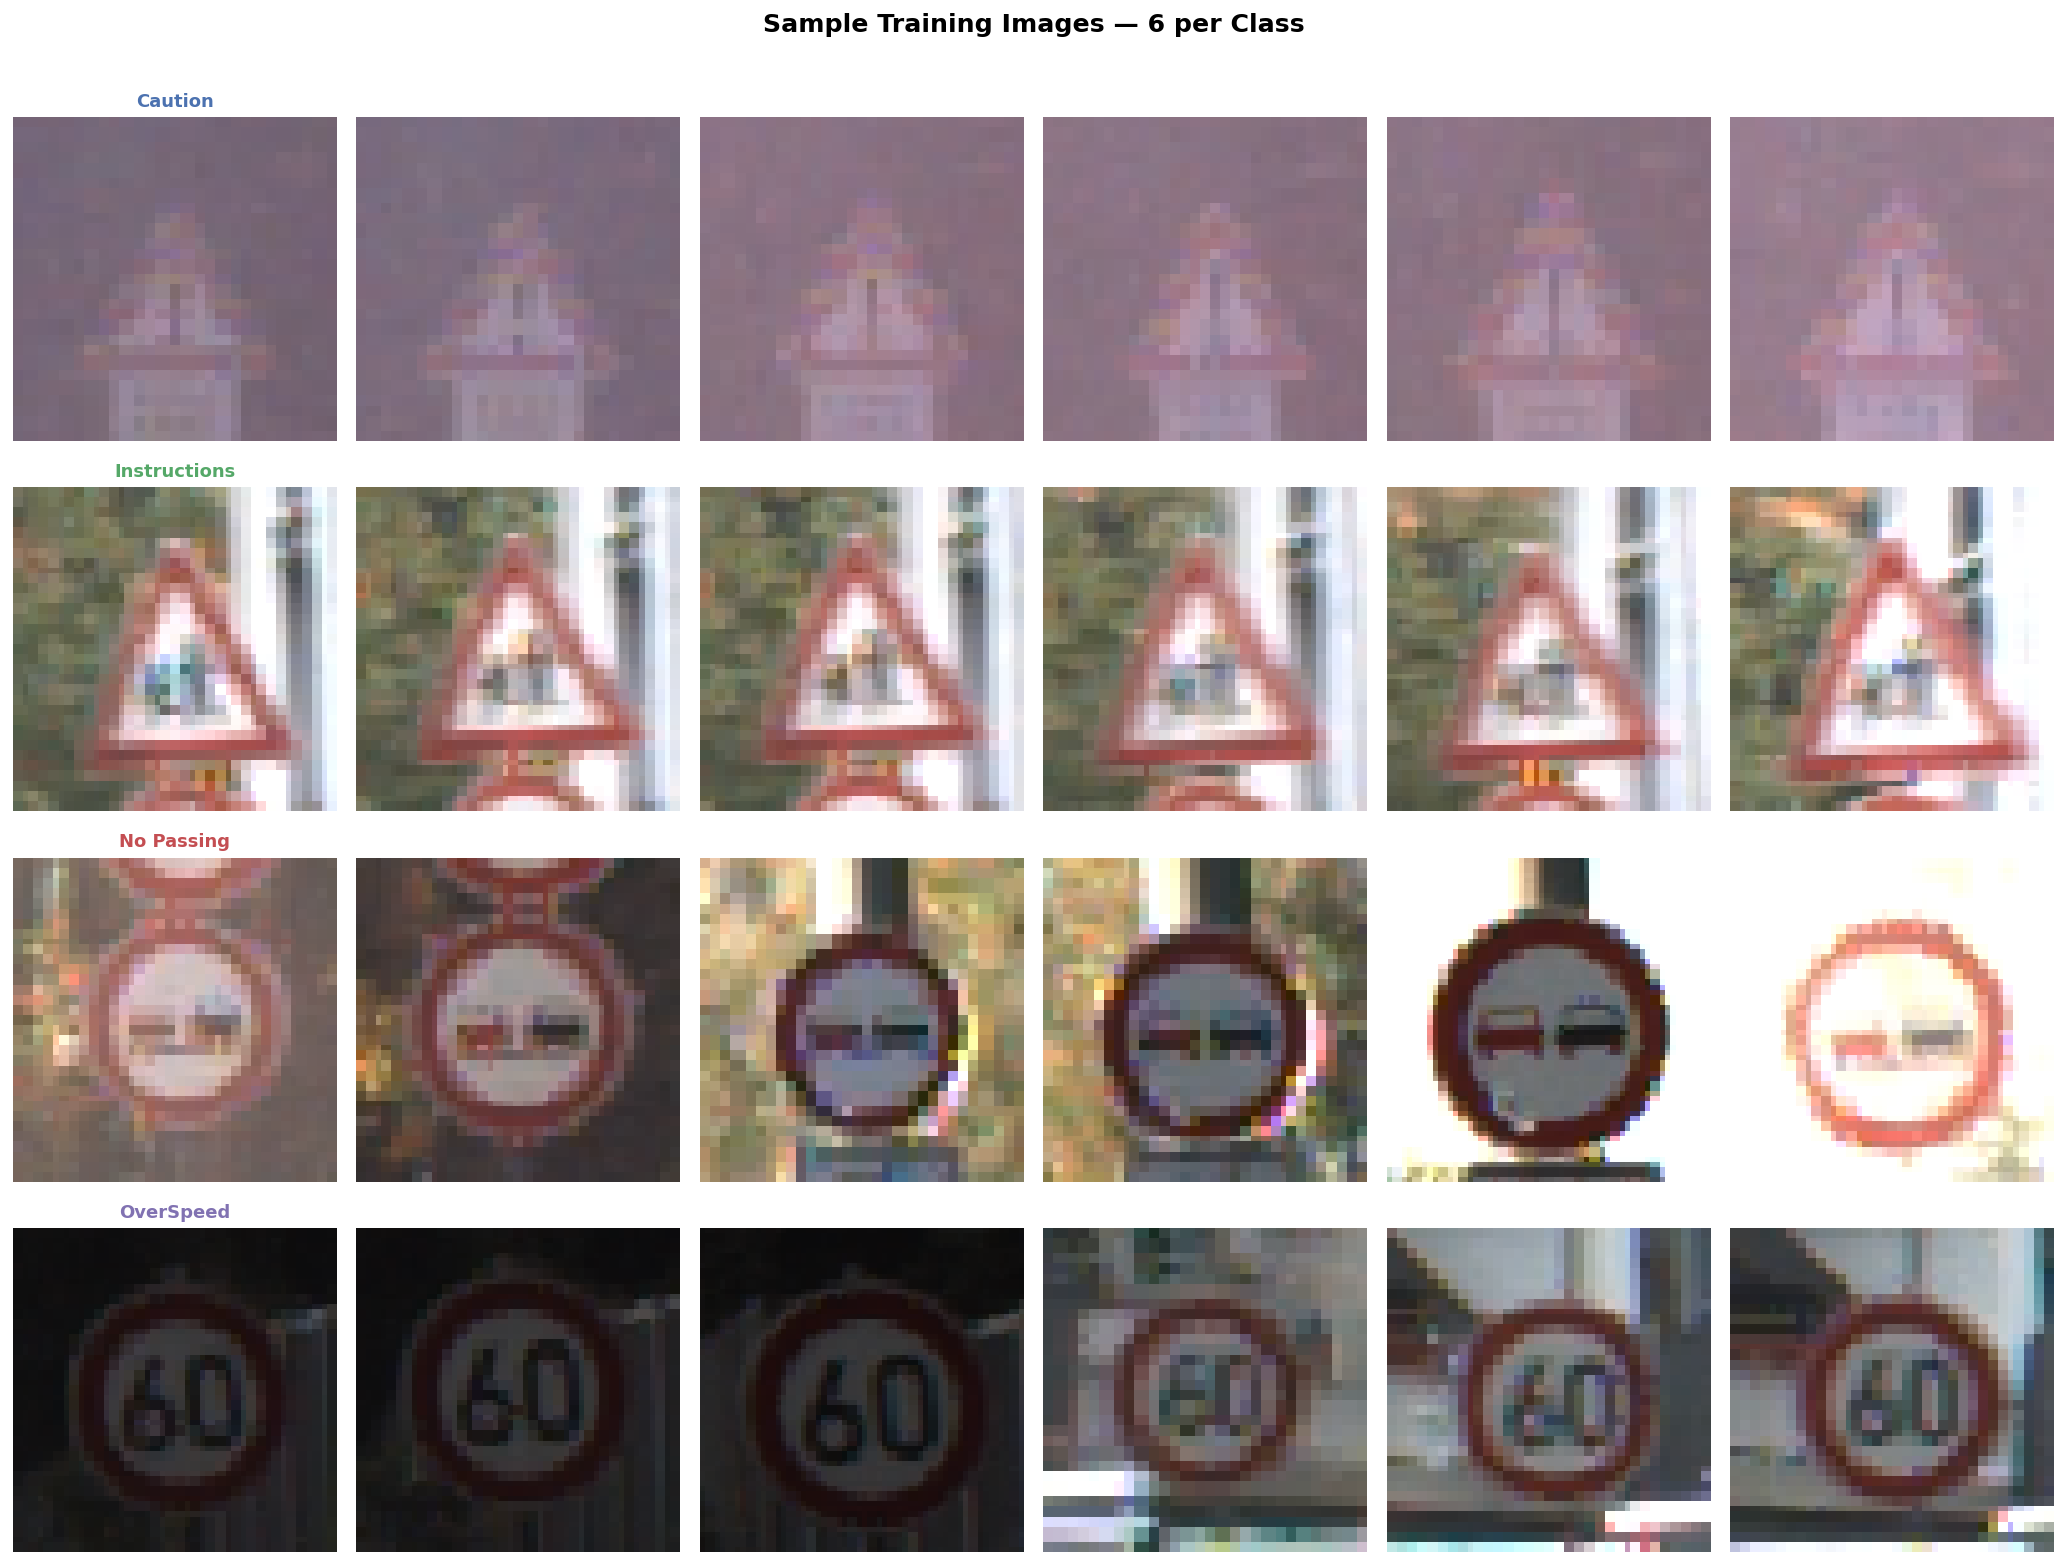

In [7]:
fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(16, 3*NUM_CLASSES))
fig.suptitle('Sample Training Images — 6 per Class', fontsize=14, fontweight='bold', y=1.01)

for row, cls in enumerate(sorted(train_counts.keys())):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    imgs    = sorted(os.listdir(cls_dir))[:6]
    for col, fname in enumerate(imgs):
        img = load_img(os.path.join(cls_dir, fname), target_size=(IMG_SIZE, IMG_SIZE))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=10, fontweight='bold', color=COLORS[row])

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Preprocessing, Generators & Augmentation

In [8]:
# ── Compute class weights to handle imbalance ─────────────────────
from sklearn.utils.class_weight import compute_class_weight

# Build a flat list of labels from the train directory
all_labels = []
class_to_idx = {cls: i for i, cls in enumerate(sorted(train_counts.keys()))}
for cls, idx in class_to_idx.items():
    all_labels.extend([idx] * train_counts[cls])

cw = compute_class_weight('balanced', classes=np.unique(all_labels), y=all_labels)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(cw)}
print('Class weights (balanced):')
for cls, idx in class_to_idx.items():
    print(f'  {cls:20s} → {CLASS_WEIGHTS[idx]:.4f}')

Class weights (balanced):
  Caution              → 0.9667
  Instructions         → 1.0474
  No Passing           → 0.9017
  OverSpeed            → 1.1090


In [9]:
# ── Part A generators (64×64, rescale to [0,1]) ───────────────────
train_aug_gen = ImageDataGenerator(
    rescale            = 1./255,
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    shear_range        = 0.10,
    zoom_range         = 0.15,
    horizontal_flip    = True,
    brightness_range   = [0.8, 1.2],
    channel_shift_range= 20.0,
    fill_mode          = 'nearest'
)

plain_gen = ImageDataGenerator(rescale=1./255)

train_generator = train_aug_gen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    seed=SEED, shuffle=True
)
val_generator = plain_gen.flow_from_directory(
    VAL_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    seed=SEED, shuffle=False
)
test_generator = plain_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical',
    shuffle=False
)

print(f'Train batches : {len(train_generator)}')
print(f'Val   batches : {len(val_generator)}')
print(f'Test  batches : {len(test_generator)}')
print(f'Class index   : {train_generator.class_indices}')
IDX_TO_CLASS = {v:k for k,v in train_generator.class_indices.items()}

Found 3163 images belonging to 4 classes.
Found 2182 images belonging to 4 classes.
Found 627 images belonging to 4 classes.
Train batches : 99
Val   batches : 69
Test  batches : 20
Class index   : {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}


### 3.1 Augmentation Visualisation — Original vs Augmented

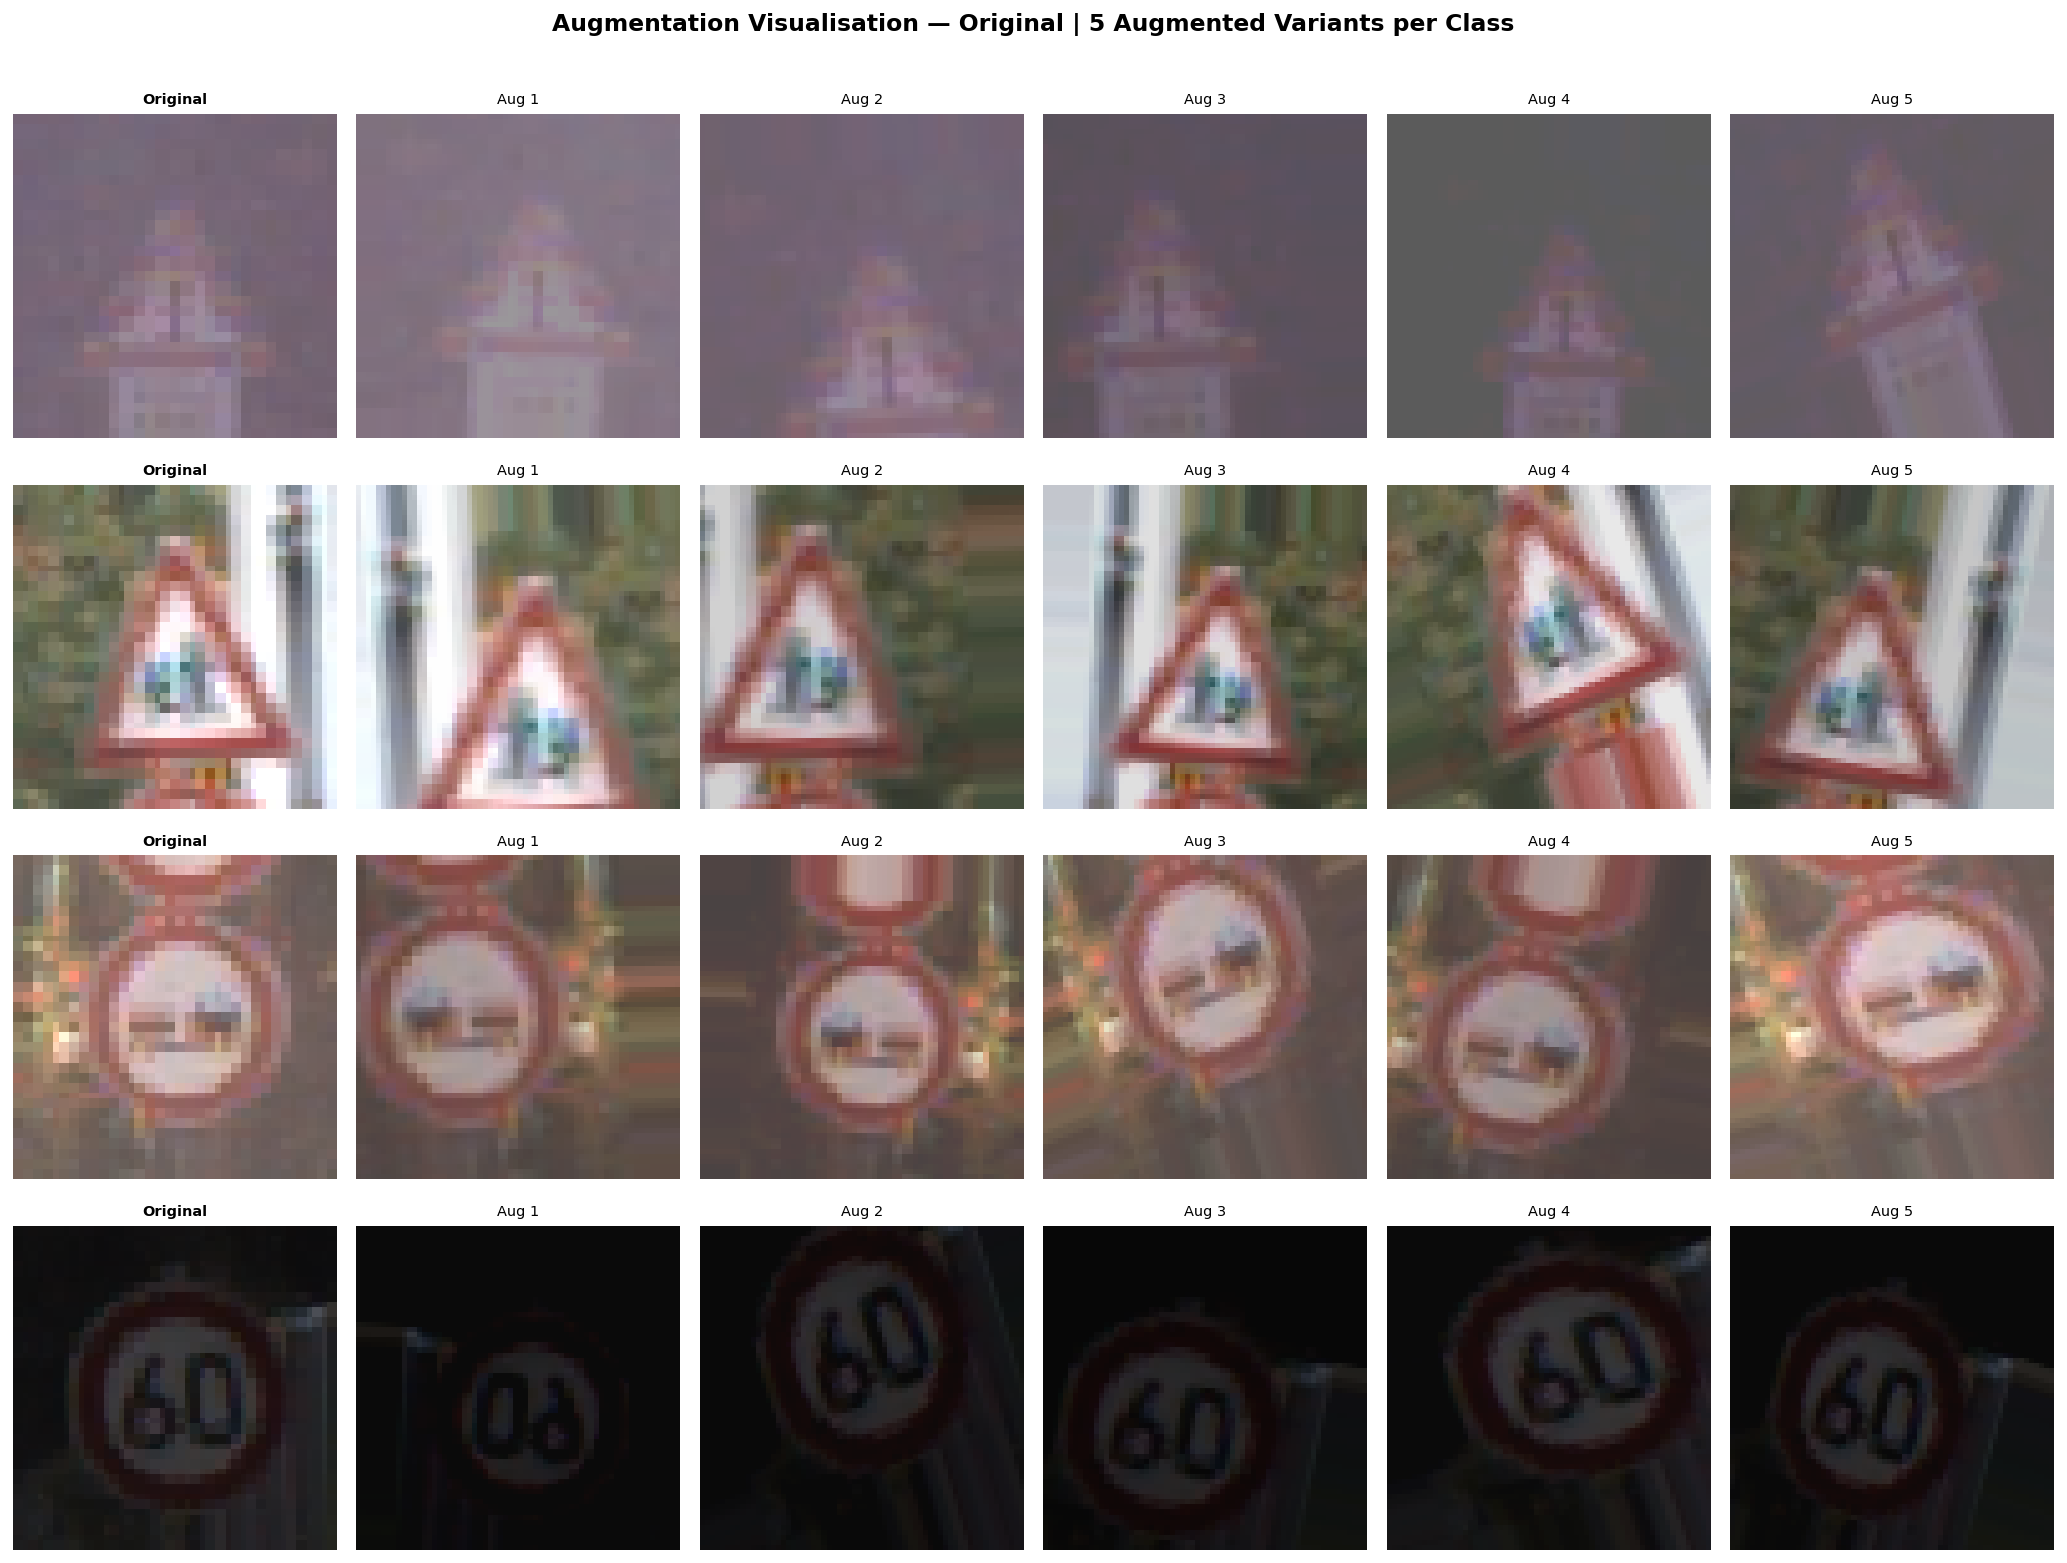

In [10]:
# Pick one image per class and show original vs 5 augmented versions
fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(16, 3*NUM_CLASSES))
fig.suptitle('Augmentation Visualisation — Original | 5 Augmented Variants per Class',
             fontsize=13, fontweight='bold', y=1.01)

aug_only = ImageDataGenerator(
    rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
    shear_range=0.10, zoom_range=0.15, horizontal_flip=True,
    brightness_range=[0.7,1.3], channel_shift_range=25.0, fill_mode='nearest'
)

for row, cls in enumerate(sorted(train_counts.keys())):
    cls_dir  = os.path.join(TRAIN_DIR, cls)
    src_path = os.path.join(cls_dir, sorted(os.listdir(cls_dir))[0])
    orig     = load_img(src_path, target_size=(IMG_SIZE, IMG_SIZE))
    orig_arr = img_to_array(orig)

    # Column 0 = original
    axes[row, 0].imshow(orig)
    axes[row, 0].set_title('Original', fontsize=8, fontweight='bold')
    axes[row, 0].axis('off')
    axes[row, 0].set_ylabel(cls, fontsize=9, fontweight='bold', color=COLORS[row])

    # Columns 1–5 = augmented
    aug_iter = aug_only.flow(orig_arr[np.newaxis], batch_size=1, seed=row)
    for col in range(1, 6):
        aug_img = next(aug_iter)[0].astype('uint8')
        axes[row, col].imshow(aug_img)
        axes[row, col].set_title(f'Aug {col}', fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_viz.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Helper Functions (Evaluation, Visualisation, Grad-CAM)

In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


# ────────────────────────────────────────────────────────────────────
#  HELPER 1 — Training curves
# ────────────────────────────────────────────────────────────────────
def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    ep = range(1, len(history.history['accuracy'])+1)

    axes[0].plot(ep, history.history['accuracy'],     label='Train', color='#2196F3', linewidth=2)
    axes[0].plot(ep, history.history['val_accuracy'], label='Val',   color='#F44336', linewidth=2, linestyle='--')
    axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_ylim(0, 1.05)

    axes[1].plot(ep, history.history['loss'],     label='Train', color='#2196F3', linewidth=2)
    axes[1].plot(ep, history.history['val_loss'], label='Val',   color='#F44336', linewidth=2, linestyle='--')
    axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ────────────────────────────────────────────────────────────────────
#  HELPER 2 — Full evaluation + confusion matrix + classification df
# ────────────────────────────────────────────────────────────────────
def evaluate_model(model, generator, class_names, model_name='Model'):
    generator.reset()
    loss, acc = model.evaluate(generator, verbose=0)

    generator.reset()
    y_prob = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes

    p  = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    r  = recall_score   (y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score       (y_true, y_pred, average='weighted', zero_division=0)

    print(f'\n{"="*58}')
    print(f'  {model_name}  —  Test Evaluation')
    print(f'{"="*58}')
    print(f'  Loss          : {loss:.4f}')
    print(f'  Accuracy      : {acc*100:.2f}%')
    print(f'  Precision (W) : {p:.4f}')
    print(f'  Recall    (W) : {r:.4f}')
    print(f'  F1-Score  (W) : {f1:.4f}')
    print(f'{"="*58}')

    # ── Classification report as styled DataFrame ──────────────────
    cr = classification_report(y_true, y_pred, target_names=class_names,
                               zero_division=0, output_dict=True)
    df_cr = pd.DataFrame(cr).T.round(3)
    print('\nClassification Report:')
    display(df_cr.style.background_gradient(cmap='Blues', subset=['precision','recall','f1-score'])
                       .format({'precision':'{:.3f}','recall':'{:.3f}','f1-score':'{:.3f}','support':'{:.0f}'}))

    # ── Confusion matrix ───────────────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')

    sns.heatmap(cm,      annot=True, fmt='d',    cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title('Raw Counts'); axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

    sns.heatmap(cm_norm, annot=True, fmt='.2f',  cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title('Normalised (Row %)'); axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return {'loss':loss,'accuracy':acc,'precision':p,'recall':r,'f1':f1,
            'y_true':y_true,'y_pred':y_pred,'y_prob':y_prob}


# ────────────────────────────────────────────────────────────────────
#  HELPER 3 — Per-class accuracy bar chart
# ────────────────────────────────────────────────────────────────────
def per_class_accuracy(y_true, y_pred, class_names, title='Per-Class Accuracy'):
    cm = confusion_matrix(y_true, y_pred)
    per_class = cm.diagonal() / cm.sum(axis=1)
    fig, ax = plt.subplots(figsize=(9,4))
    bars = ax.bar(class_names, per_class*100, color=COLORS, edgecolor='black', linewidth=0.6)
    for bar, v in zip(bars, per_class):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{v*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 115); ax.set_ylabel('Accuracy (%)')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.axhline(np.mean(per_class)*100, color='red', linestyle='--', label=f'Mean {np.mean(per_class)*100:.1f}%')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{title.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ────────────────────────────────────────────────────────────────────
#  HELPER 4 — Misclassified samples
# ────────────────────────────────────────────────────────────────────
def show_misclassified(model, generator, class_names, n=12, title='Misclassified Samples'):
    generator.reset()
    all_imgs, all_true, all_pred = [], [], []
    for imgs, labels in generator:
        preds = np.argmax(model.predict(imgs, verbose=0), axis=1)
        trues = np.argmax(labels, axis=1)
        for i in range(len(imgs)):
            if preds[i] != trues[i]:
                all_imgs.append(imgs[i])
                all_true.append(trues[i])
                all_pred.append(preds[i])
        if len(all_imgs) >= n: break

    n = min(n, len(all_imgs))
    if n == 0:
        print('No misclassified samples found (perfect model!)')
        return

    cols = 4; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4*rows))
    fig.suptitle(f'Misclassified Samples — {title}', fontsize=13, fontweight='bold')
    axes = axes.flat
    for i in range(n):
        axes[i].imshow(all_imgs[i])
        axes[i].set_title(
            f'True: {class_names[all_true[i]]}\nPred: {class_names[all_pred[i]]}',
            color='red', fontsize=8
        )
        axes[i].axis('off')
    for i in range(n, len(list(axes))):
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig(f'misclassified_{title.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ────────────────────────────────────────────────────────────────────
#  HELPER 5 — Inference demo on a single image
# ────────────────────────────────────────────────────────────────────
def predict_single_image(model, img_path, class_names, img_size=64, preprocess_fn=None):
    img = load_img(img_path, target_size=(img_size, img_size))
    arr = img_to_array(img)
    if preprocess_fn:
        arr = preprocess_fn(arr)
    else:
        arr = arr / 255.0
    probs = model.predict(arr[np.newaxis], verbose=0)[0]
    pred_idx = np.argmax(probs)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img); axes[0].axis('off')
    axes[0].set_title(f'Predicted: {class_names[pred_idx]}\nConfidence: {probs[pred_idx]*100:.1f}%',
                      fontsize=12, fontweight='bold', color='green')
    bars = axes[1].barh(class_names, probs*100, color=COLORS, edgecolor='black', linewidth=0.5)
    axes[1].set_xlabel('Confidence (%)')
    axes[1].set_title('Class Probabilities')
    axes[1].set_xlim(0, 115)
    for bar, p in zip(bars, probs):
        axes[1].text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
                     f'{p*100:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
    return class_names[pred_idx], probs


# ────────────────────────────────────────────────────────────────────
#  HELPER 6 — Grad-CAM
# ────────────────────────────────────────────────────────────────────
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        model.inputs,
        [model.get_layer(last_conv_layer_name).output, model.layers[-1].output] # Changed model.output to model.layers[-1].output
    )
    with tf.GradientTape() as tape:
        conv_outputs, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]
    grads      = tape.gradient(class_channel, conv_outputs)
    pooled     = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out   = conv_outputs[0]
    heatmap    = conv_out @ pooled[..., tf.newaxis]
    heatmap    = tf.squeeze(heatmap).numpy()
    heatmap    = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    return heatmap

def show_gradcam(model, img_path, last_conv_layer, class_names, img_size=64, preprocess_fn=None):
    img  = load_img(img_path, target_size=(img_size, img_size))
    arr  = img_to_array(img)
    inp  = (preprocess_fn(arr.copy()) if preprocess_fn else arr/255.0)[np.newaxis]
    pred = np.argmax(model.predict(inp, verbose=0)[0])
    hm   = make_gradcam_heatmap(inp, model, last_conv_layer, pred)
    hm_resized = np.array(Image.fromarray(np.uint8(255*hm)).resize((img_size, img_size)))
    overlay = np.array(img, dtype='float32')
    colored = plt.cm.jet(hm_resized / 255.0)[..., :3] * 255
    superimposed = overlay * 0.55 + colored * 0.45
    superimposed = np.clip(superimposed, 0, 255).astype('uint8')
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img);             axes[0].set_title('Original');      axes[0].axis('off')
    axes[1].imshow(hm, cmap='jet');  axes[1].set_title('Grad-CAM');      axes[1].axis('off')
    axes[2].imshow(superimposed);    axes[2].set_title(f'Overlay — Pred: {class_names[pred]}'); axes[2].axis('off')
    plt.suptitle('Grad-CAM Visualisation — Where the Model Looks', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('gradcam.png', dpi=150, bbox_inches='tight')
    plt.show()

print('All helper functions defined successfully.')

All helper functions defined successfully.


---
## Section 5 — Part A: Baseline CNN (3 Conv Blocks + 3 FC Layers)

### 5.1 Architecture Design & Rationale

The baseline follows the assignment specification exactly:
- **3 × Conv2D → MaxPool** blocks with progressively doubling filters (32→64→128)
- **3 × Dense** fully connected layers (512→256→128)
- **Softmax** output for 4-class probability distribution
- All Conv kernels: 3×3 with `same` padding to preserve spatial dimensions
- Optimiser: **Adam** (lr=1e-3) | Loss: **Categorical Cross-Entropy**

In [12]:
def build_baseline(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    model = models.Sequential(name='Baseline_CNN', layers=[
        # ── Block 1 ────────────────────────────────
        layers.Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=input_shape, name='conv1'),
        layers.MaxPooling2D((2,2), name='pool1'),
        # ── Block 2 ────────────────────────────────
        layers.Conv2D(64,  (3,3), activation='relu', padding='same', name='conv2'),
        layers.MaxPooling2D((2,2), name='pool2'),
        # ── Block 3 ────────────────────────────────
        layers.Conv2D(128, (3,3), activation='relu', padding='same', name='conv3'),
        layers.MaxPooling2D((2,2), name='pool3'),
        # ── Dense head ─────────────────────────────
        layers.Flatten(name='flatten'),
        layers.Dense(512, activation='relu', name='fc1'),
        layers.Dense(256, activation='relu', name='fc2'),
        layers.Dense(128, activation='relu', name='fc3'),
        layers.Dense(num_classes, activation='softmax', name='output'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline()
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc3 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,452,804 (16.99 MB)

 Trainable params: 4,452,804 (16.99 MB)

 Non-trainable params: 0 (0.00 B)

### 5.2 Early Stopping & Learning Rate Scheduling — Rationale

| Callback | Setting | Purpose |
|---|---|---|
| `EarlyStopping` | patience=7, restore best weights | Halts training when val_loss stops improving; prevents overfitting |
| `ReduceLROnPlateau` | factor=0.5, patience=3, min_lr=1e-7 | Halves LR when stuck; allows finer convergence near optima |
| `ModelCheckpoint` | monitor=val_accuracy | Saves only the epoch with highest validation accuracy |

**Why `patience=7`?** A patience too small (e.g., 2–3) risks premature stopping during temporary plateaus. Seven epochs gives the model sufficient time to escape local minima before termination.

In [13]:
def get_callbacks(name, patience_es=7, patience_lr=3):
    return [
        EarlyStopping(monitor='val_loss', patience=patience_es,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=patience_lr,
                          min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'{name}_best.keras', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

t0 = time.time()
history_baseline = baseline_model.fit(
    train_generator,
    validation_data = val_generator,
    epochs          = 30,
    callbacks       = get_callbacks('baseline'),
    class_weight    = CLASS_WEIGHTS,
    verbose         = 1
)
baseline_train_time = time.time() - t0
print(f'\nBaseline training time: {baseline_train_time:.0f}s ({baseline_train_time/60:.1f} min)')

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 36s 282ms/step - accuracy: 0.5191 - loss: 1.0204 - val_accuracy: 0.8258 - val_loss: 0.5383 - learning_rate: 0.0010
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 23s 232ms/step - accuracy: 0.7872 - loss: 0.5678 - val_accuracy: 0.9161 - val_loss: 0.3788 - learning_rate: 0.0010
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 242ms/step - accuracy: 0.8960 - loss: 0.2868 - val_accuracy: 0.9592 - val_loss: 0.3213 - learning_rate: 0.0010
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 237ms/step - accuracy: 0.9339 - loss: 0.1957 - val_accuracy: 0.9519 - val_loss: 0.2975 - learning_rate: 0.0010
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 23s 234ms/step - accuracy: 0.9327 - loss: 0.1841 - val_accuracy: 0.9684 - val_loss: 0.2676 - learning_rate: 0.0010
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 239ms/step - accuracy: 0.9475 - loss: 0.1465 - val_accuracy: 0.9413 - val_loss: 0.4033 - learning_rate: 0.0010
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 22s 226ms/step - accuracy: 0.9611 - loss: 0.

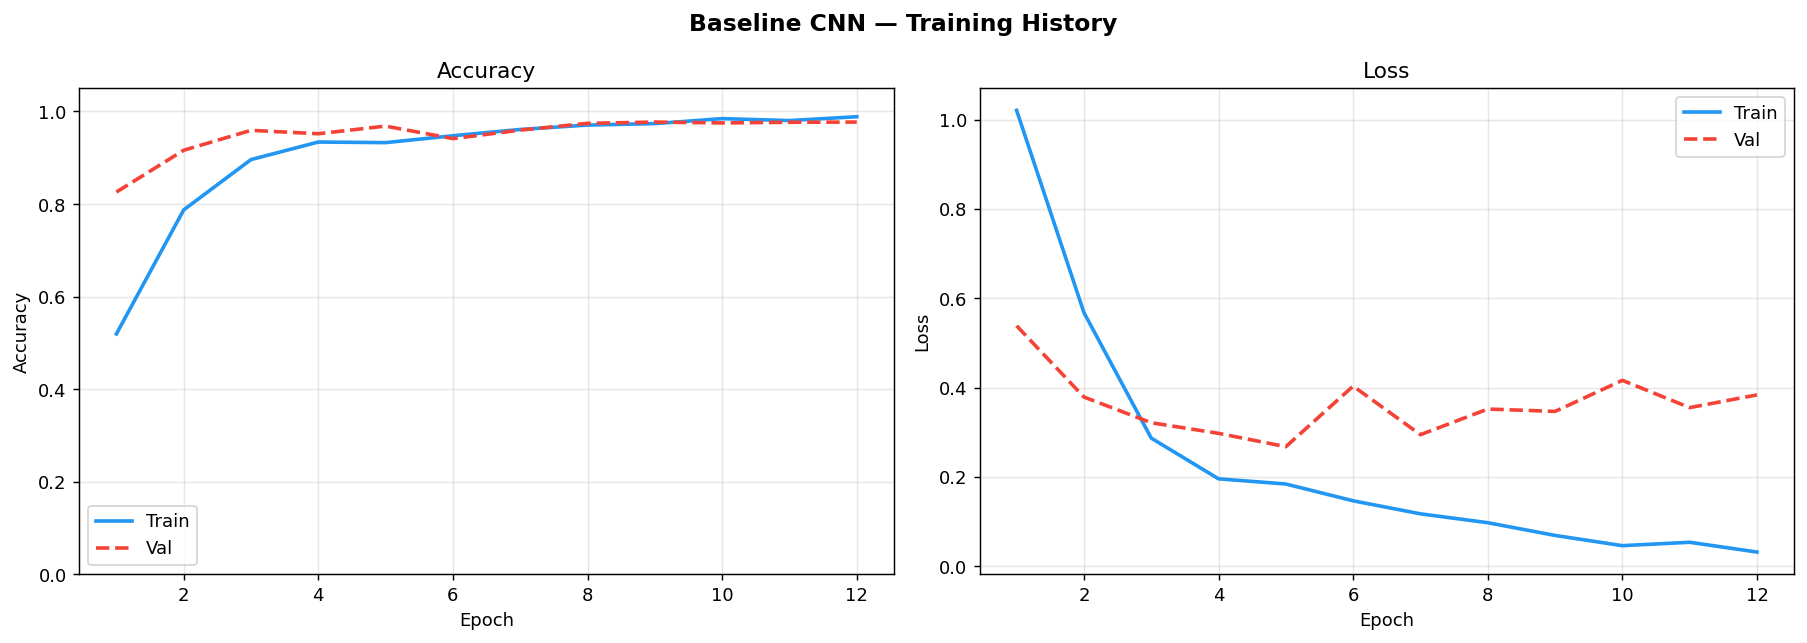

In [14]:
plot_history(history_baseline, 'Baseline CNN — Training History')


  Baseline CNN  —  Test Evaluation
  Loss          : 6.2681
  Accuracy      : 40.03%
  Precision (W) : 0.4431
  Recall    (W) : 0.4003
  F1-Score  (W) : 0.4121

Classification Report:


,precision,recall,f1-score,support
Caution,0.270,0.352,0.305,108
Instructions,0.454,0.340,0.388,159
No Passing,0.216,0.450,0.292,60
OverSpeed,0.545,0.440,0.487,300
accuracy,0.400,0.400,0.400,0
macro avg,0.371,0.395,0.368,627
weighted avg,0.443,0.400,0.412,627


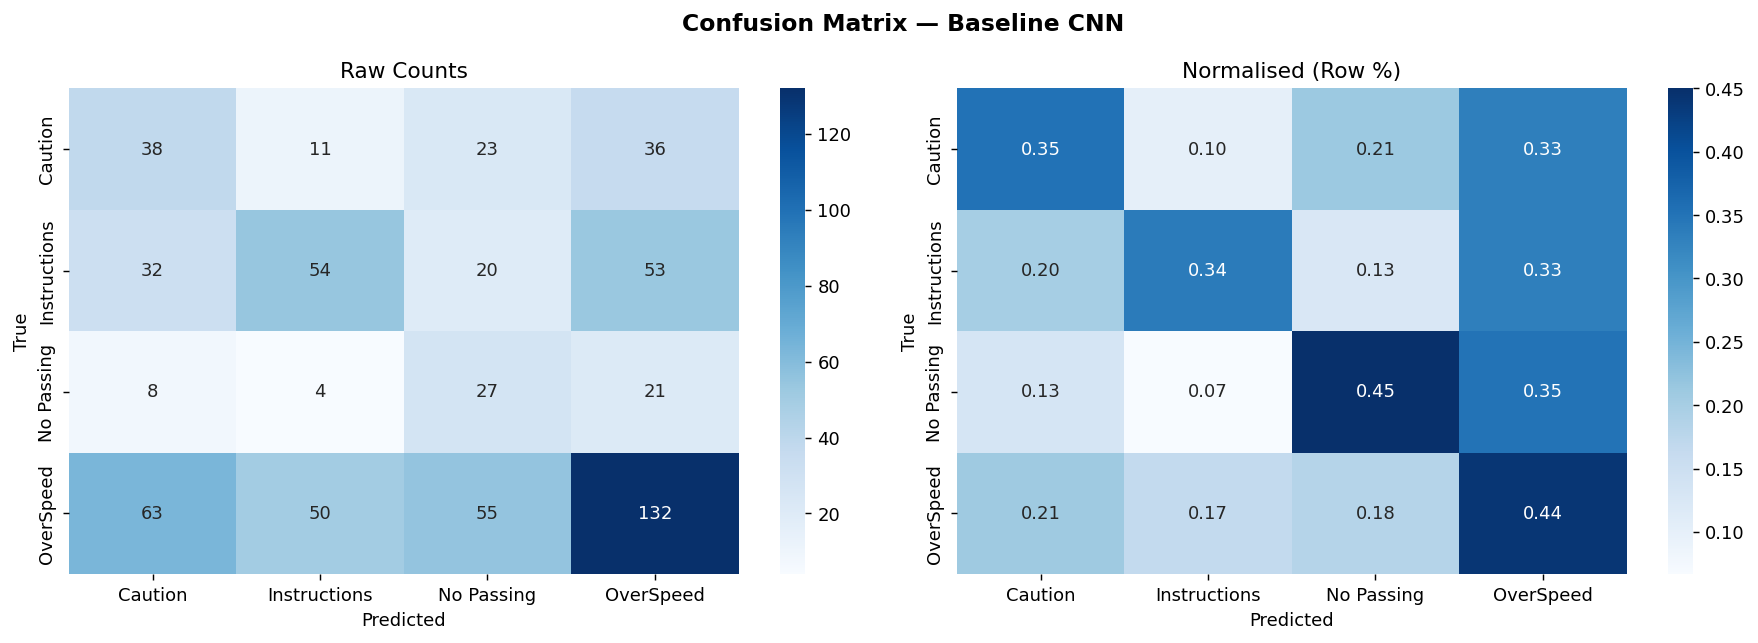

In [15]:
metrics_baseline = evaluate_model(baseline_model, test_generator, CLASS_NAMES, 'Baseline CNN')

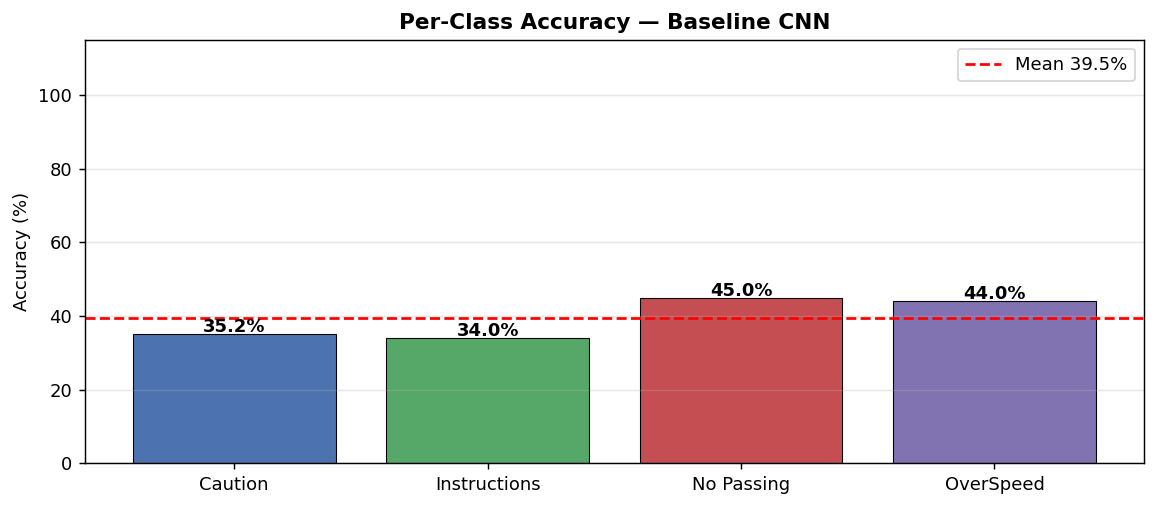

In [16]:
per_class_accuracy(metrics_baseline['y_true'], metrics_baseline['y_pred'],
                   CLASS_NAMES, 'Per-Class Accuracy — Baseline CNN')

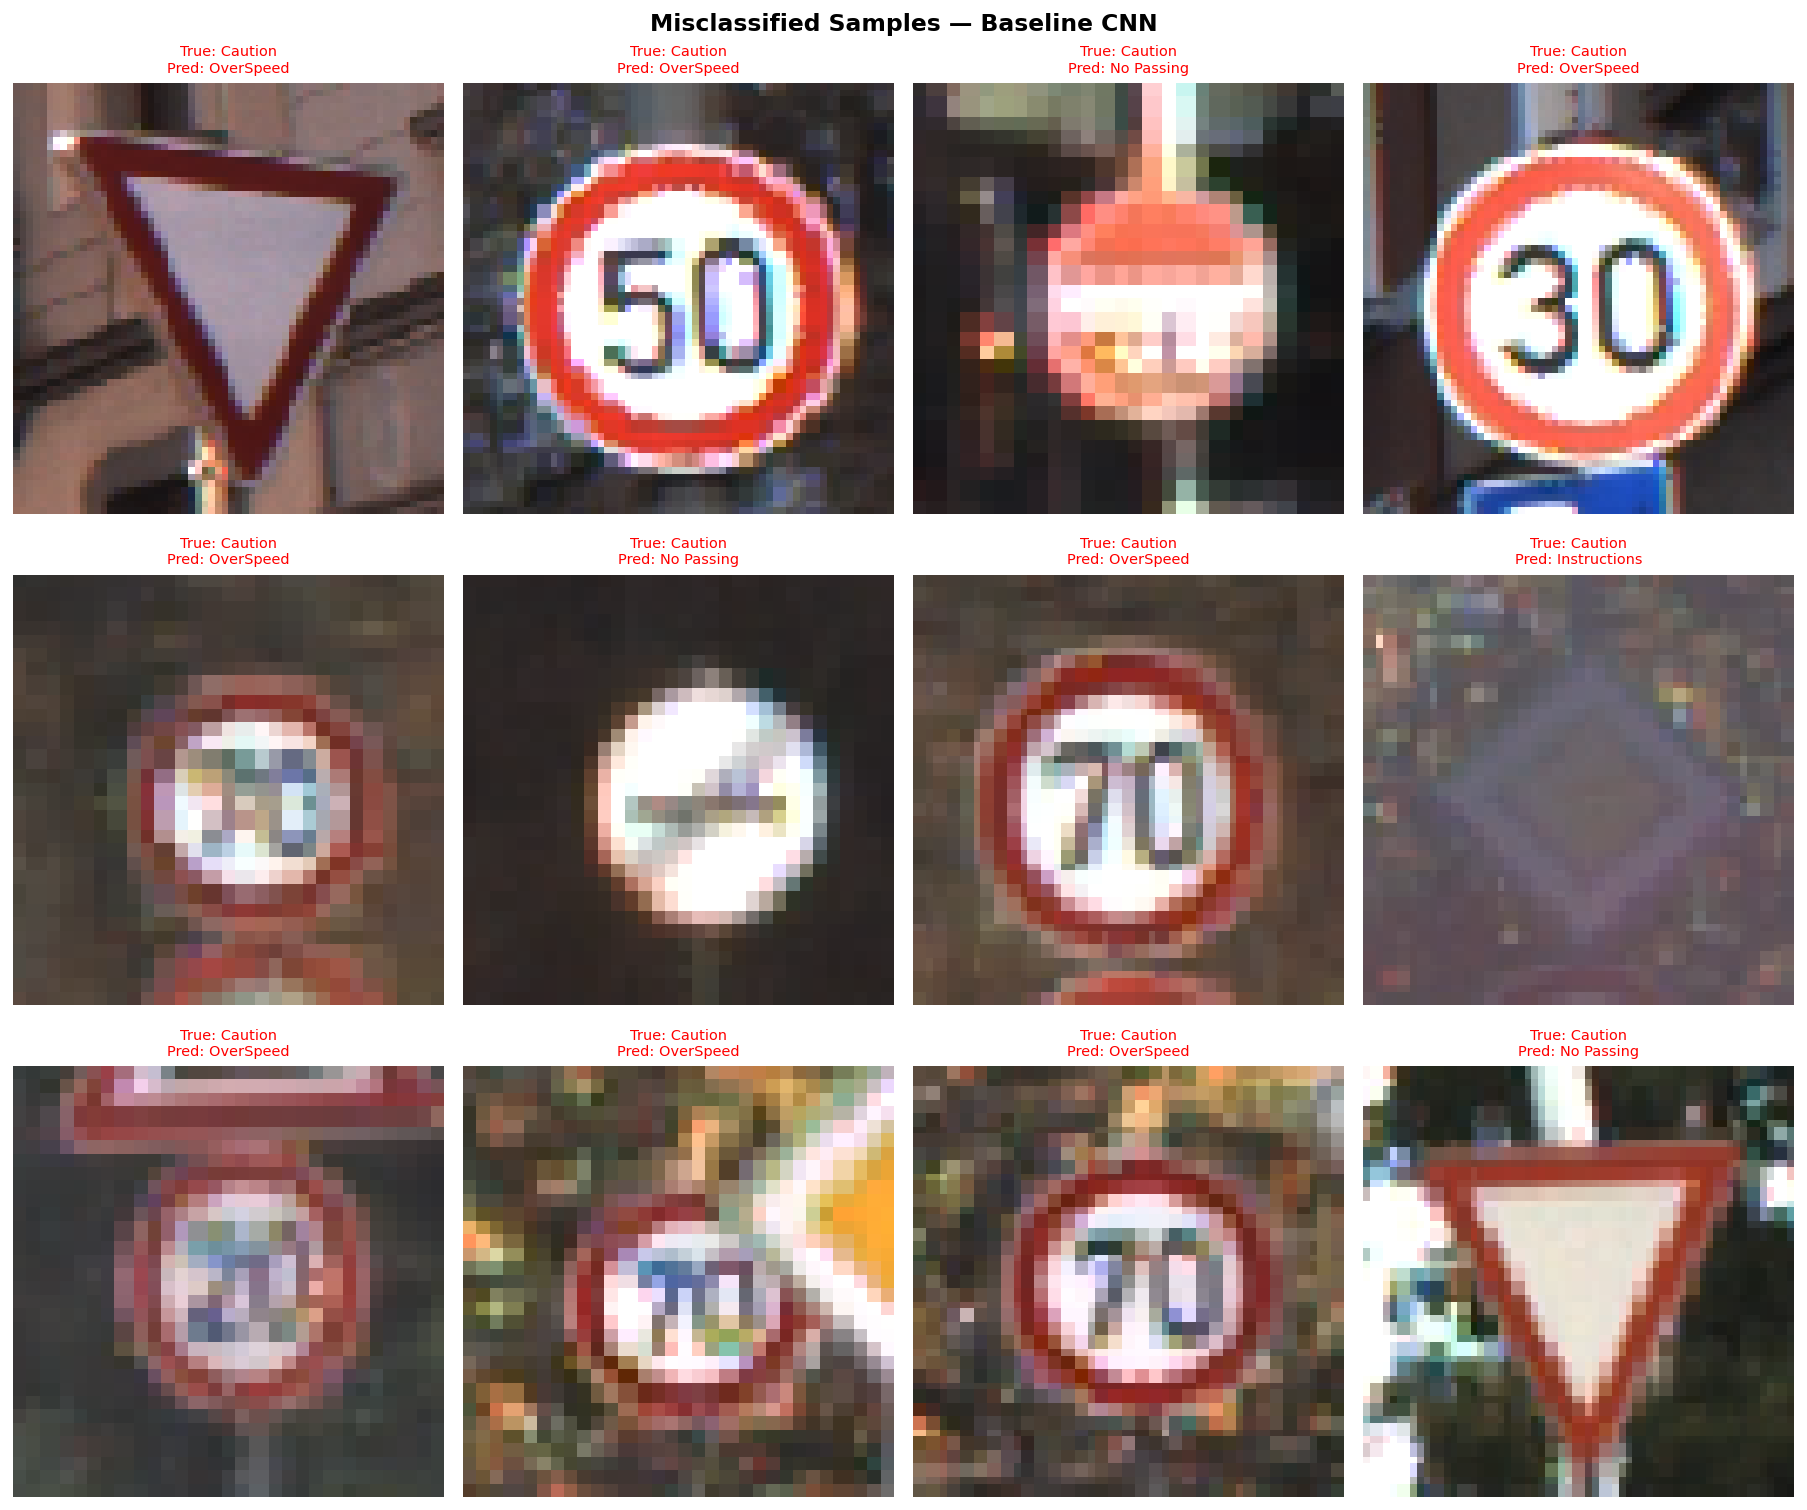

In [17]:
show_misclassified(baseline_model, test_generator, CLASS_NAMES,
                   n=12, title='Baseline CNN')

### 5.3 Grad-CAM — Where Does the Baseline CNN Look?

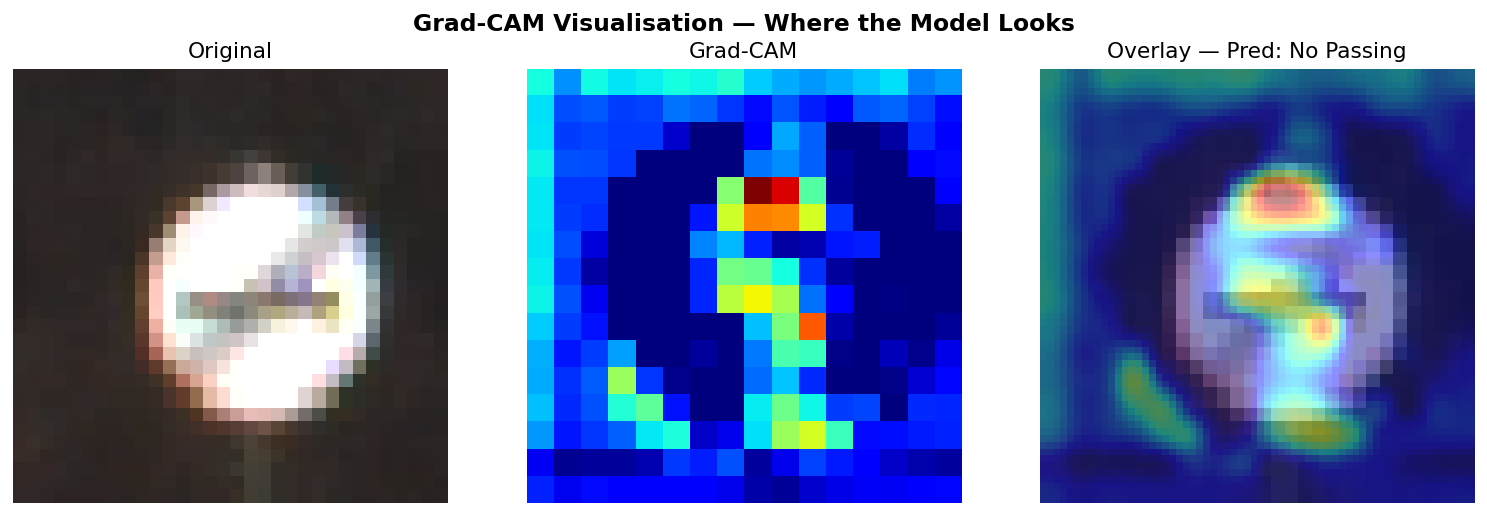

In [20]:
# Pick a test sample from the first class for Grad-CAM demo
sample_cls  = sorted(os.listdir(TEST_DIR))[0]
sample_imgs = os.listdir(os.path.join(TEST_DIR, sample_cls))
sample_path = os.path.join(TEST_DIR, sample_cls, sample_imgs[0])

show_gradcam(baseline_model, sample_path,
             last_conv_layer='conv3',
             class_names=CLASS_NAMES,
             img_size=IMG_SIZE)

---
## Section 6 — Part A: Deeper CNN with Batch Normalisation & Dropout

### 6.1 Architecture Design — Regularisation Rationale

The deeper model **doubles** the convolutional blocks (3→6 individual conv layers in 3 paired blocks).

**Batch Normalisation** after each Conv layer:
- Normalises mini-batch activations → stabilises gradient flow
- Acts as mild regulariser by introducing noise in batch statistics (Ioffe & Szegedy, 2015)
- Allows higher learning rates and accelerates convergence

**Dropout** rates:
- After each pooling: 0.25 (light, preserves spatial feature richness)
- After FC1: 0.50 (aggressive, prevents dense head over-fitting)
- After FC2: 0.40

In [21]:
def build_deeper(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    model = models.Sequential(name='Deeper_CNN')

    # ── Block 1 (double conv) ───────────────────────────────────────
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu',
                            input_shape=input_shape, name='conv1a'))
    model.add(layers.BatchNormalization(name='bn1a'))
    model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu', name='conv1b'))
    model.add(layers.BatchNormalization(name='bn1b'))
    model.add(layers.MaxPooling2D((2,2), name='pool1'))
    model.add(layers.Dropout(0.25, name='drop1'))

    # ── Block 2 ─────────────────────────────────────────────────────
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu', name='conv2a'))
    model.add(layers.BatchNormalization(name='bn2a'))
    model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu', name='conv2b'))
    model.add(layers.BatchNormalization(name='bn2b'))
    model.add(layers.MaxPooling2D((2,2), name='pool2'))
    model.add(layers.Dropout(0.25, name='drop2'))

    # ── Block 3 ─────────────────────────────────────────────────────
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu', name='conv3a'))
    model.add(layers.BatchNormalization(name='bn3a'))
    model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu', name='conv3b'))
    model.add(layers.BatchNormalization(name='bn3b'))
    model.add(layers.MaxPooling2D((2,2), name='pool3'))
    model.add(layers.Dropout(0.25, name='drop3'))

    # ── Dense head ──────────────────────────────────────────────────
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(512, activation='relu', name='fc1'))
    model.add(layers.BatchNormalization(name='bn_fc1'))
    model.add(layers.Dropout(0.50, name='drop_fc1'))
    model.add(layers.Dense(256, activation='relu', name='fc2'))
    model.add(layers.BatchNormalization(name='bn_fc2'))
    model.add(layers.Dropout(0.40, name='drop_fc2'))
    model.add(layers.Dense(128, activation='relu', name='fc3'))
    model.add(layers.Dropout(0.30, name='drop_fc3'))
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))
    return model

deeper_model = build_deeper()
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1a (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1a (BatchNormalization)       │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1b (Conv2D)                 │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1b (BatchNormalization)       │ (None, 64, 64, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2a (Conv2D)                 │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2a (BatchNormalization)       │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2b (Conv2D)                 │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2b (BatchNormalization)       │ (None, 32, 32, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3a (Conv2D)                 │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3a (BatchNormalization)       │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3b (Conv2D)                 │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3b (BatchNormalization)       │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop3 (Dropout)                 │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc1 (BatchNormalization)     │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_fc2 (BatchNormalization)     │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc2 (Dropout)              │ (None, 256)            │             

 Total params: 4,651,428 (17.74 MB)

 Trainable params: 4,648,996 (17.73 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [22]:
t0 = time.time()
history_deeper_adam = deeper_model.fit(
    train_generator,
    validation_data = val_generator,
    epochs          = 40,
    callbacks       = get_callbacks('deeper_adam'),
    class_weight    = CLASS_WEIGHTS,
    verbose         = 1
)
deeper_adam_time = time.time() - t0
print(f'Deeper (Adam) training time: {deeper_adam_time:.0f}s ({deeper_adam_time/60:.1f} min)')

Epoch 1/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 51s 351ms/step - accuracy: 0.4622 - loss: 1.3678 - val_accuracy: 0.3249 - val_loss: 1.5844 - learning_rate: 0.0010
Epoch 2/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 238ms/step - accuracy: 0.5849 - loss: 1.0047 - val_accuracy: 0.2447 - val_loss: 1.4189 - learning_rate: 0.0010
Epoch 3/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 239ms/step - accuracy: 0.7038 - loss: 0.7536 - val_accuracy: 0.6123 - val_loss: 0.9376 - learning_rate: 0.0010
Epoch 4/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 23s 235ms/step - accuracy: 0.7717 - loss: 0.5858 - val_accuracy: 0.8593 - val_loss: 0.4497 - learning_rate: 0.0010
Epoch 5/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 239ms/step - accuracy: 0.8539 - loss: 0.4032 - val_accuracy: 0.8153 - val_loss: 0.5484 - learning_rate: 0.0010
Epoch 6/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 239ms/step - accuracy: 0.8476 - loss: 0.3945 - val_accuracy: 0.9381 - val_loss: 0.2967 - learning_rate: 0.0010
Epoch 7/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 23s 234ms/step - accuracy: 0.8821 - loss: 0.

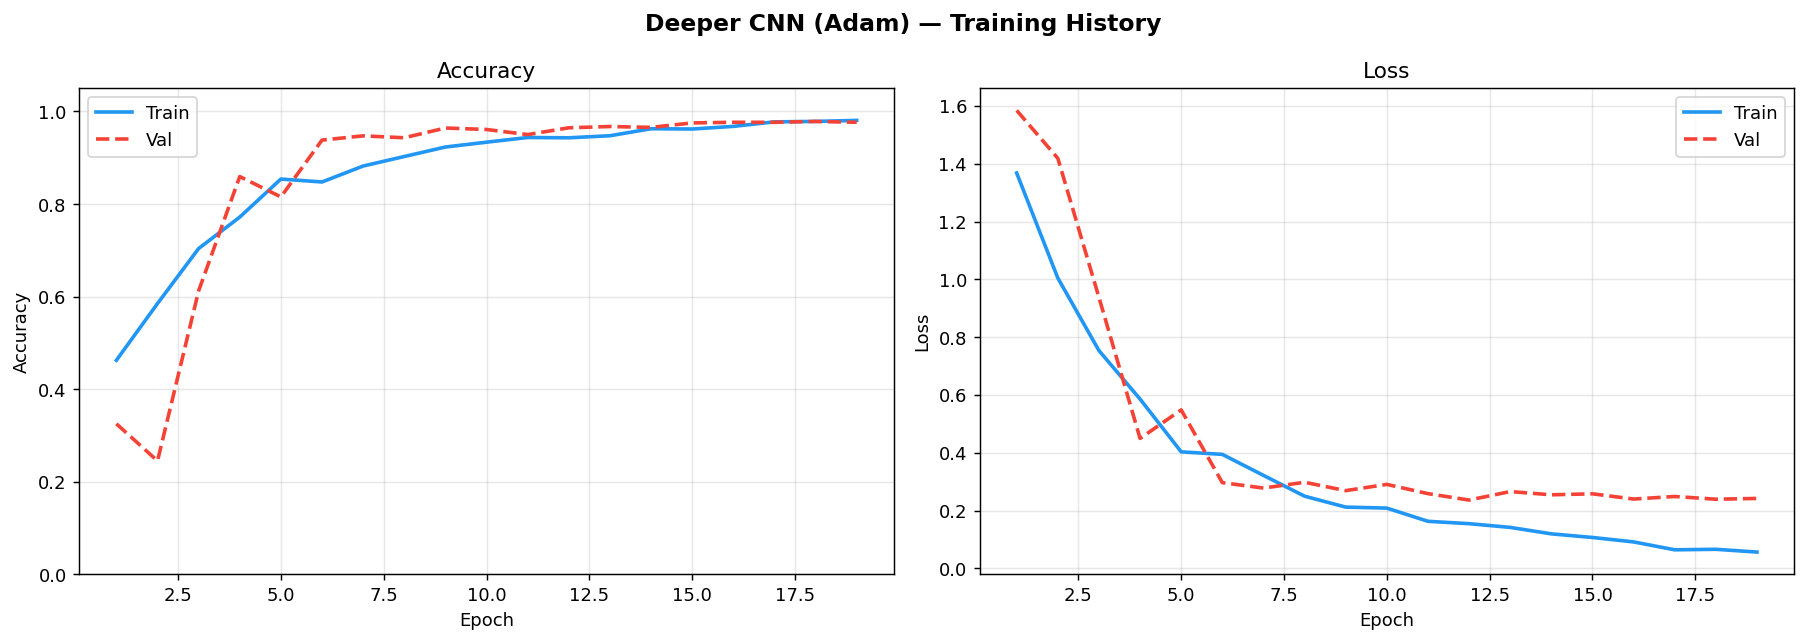

In [23]:
plot_history(history_deeper_adam, 'Deeper CNN (Adam) — Training History')


  Deeper CNN Adam  —  Test Evaluation
  Loss          : 5.1780
  Accuracy      : 40.83%
  Precision (W) : 0.4400
  Recall    (W) : 0.4083
  F1-Score  (W) : 0.4188

Classification Report:


,precision,recall,f1-score,support
Caution,0.265,0.333,0.295,108
Instructions,0.429,0.377,0.401,159
No Passing,0.223,0.383,0.282,60
OverSpeed,0.552,0.457,0.500,300
accuracy,0.408,0.408,0.408,0
macro avg,0.367,0.388,0.370,627
weighted avg,0.440,0.408,0.419,627


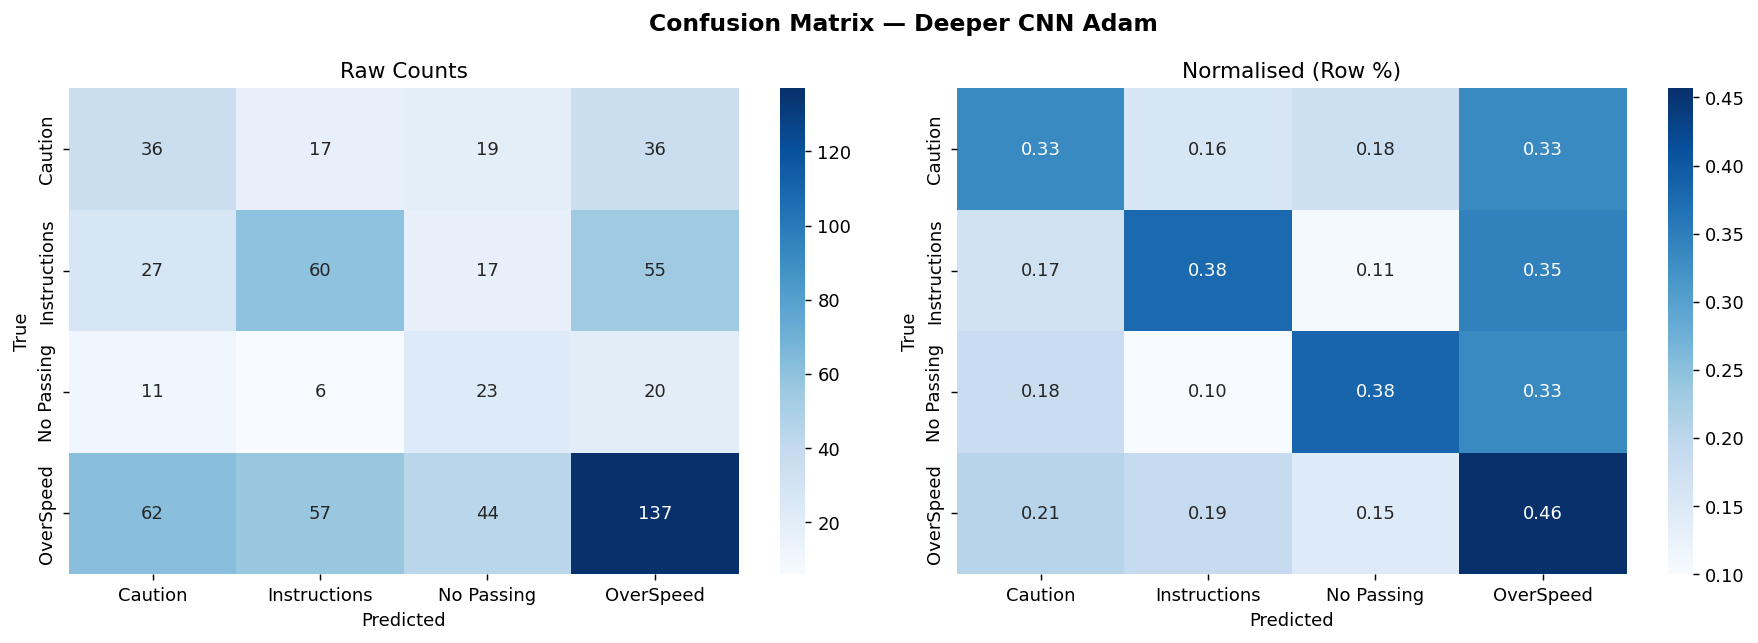

In [24]:
metrics_deeper_adam = evaluate_model(deeper_model, test_generator, CLASS_NAMES, 'Deeper CNN Adam')

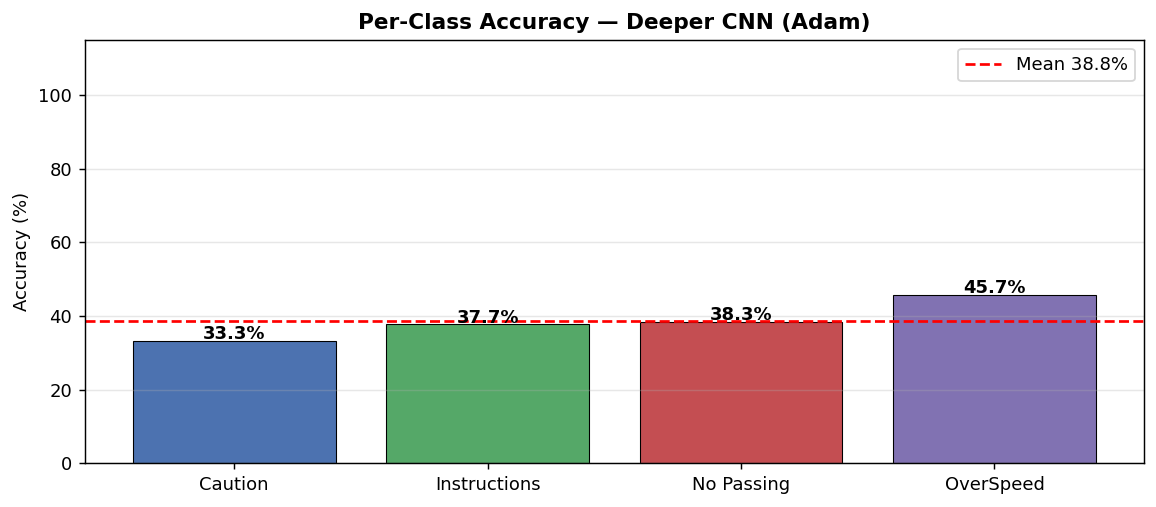

In [25]:
per_class_accuracy(metrics_deeper_adam['y_true'], metrics_deeper_adam['y_pred'],
                   CLASS_NAMES, 'Per-Class Accuracy — Deeper CNN (Adam)')

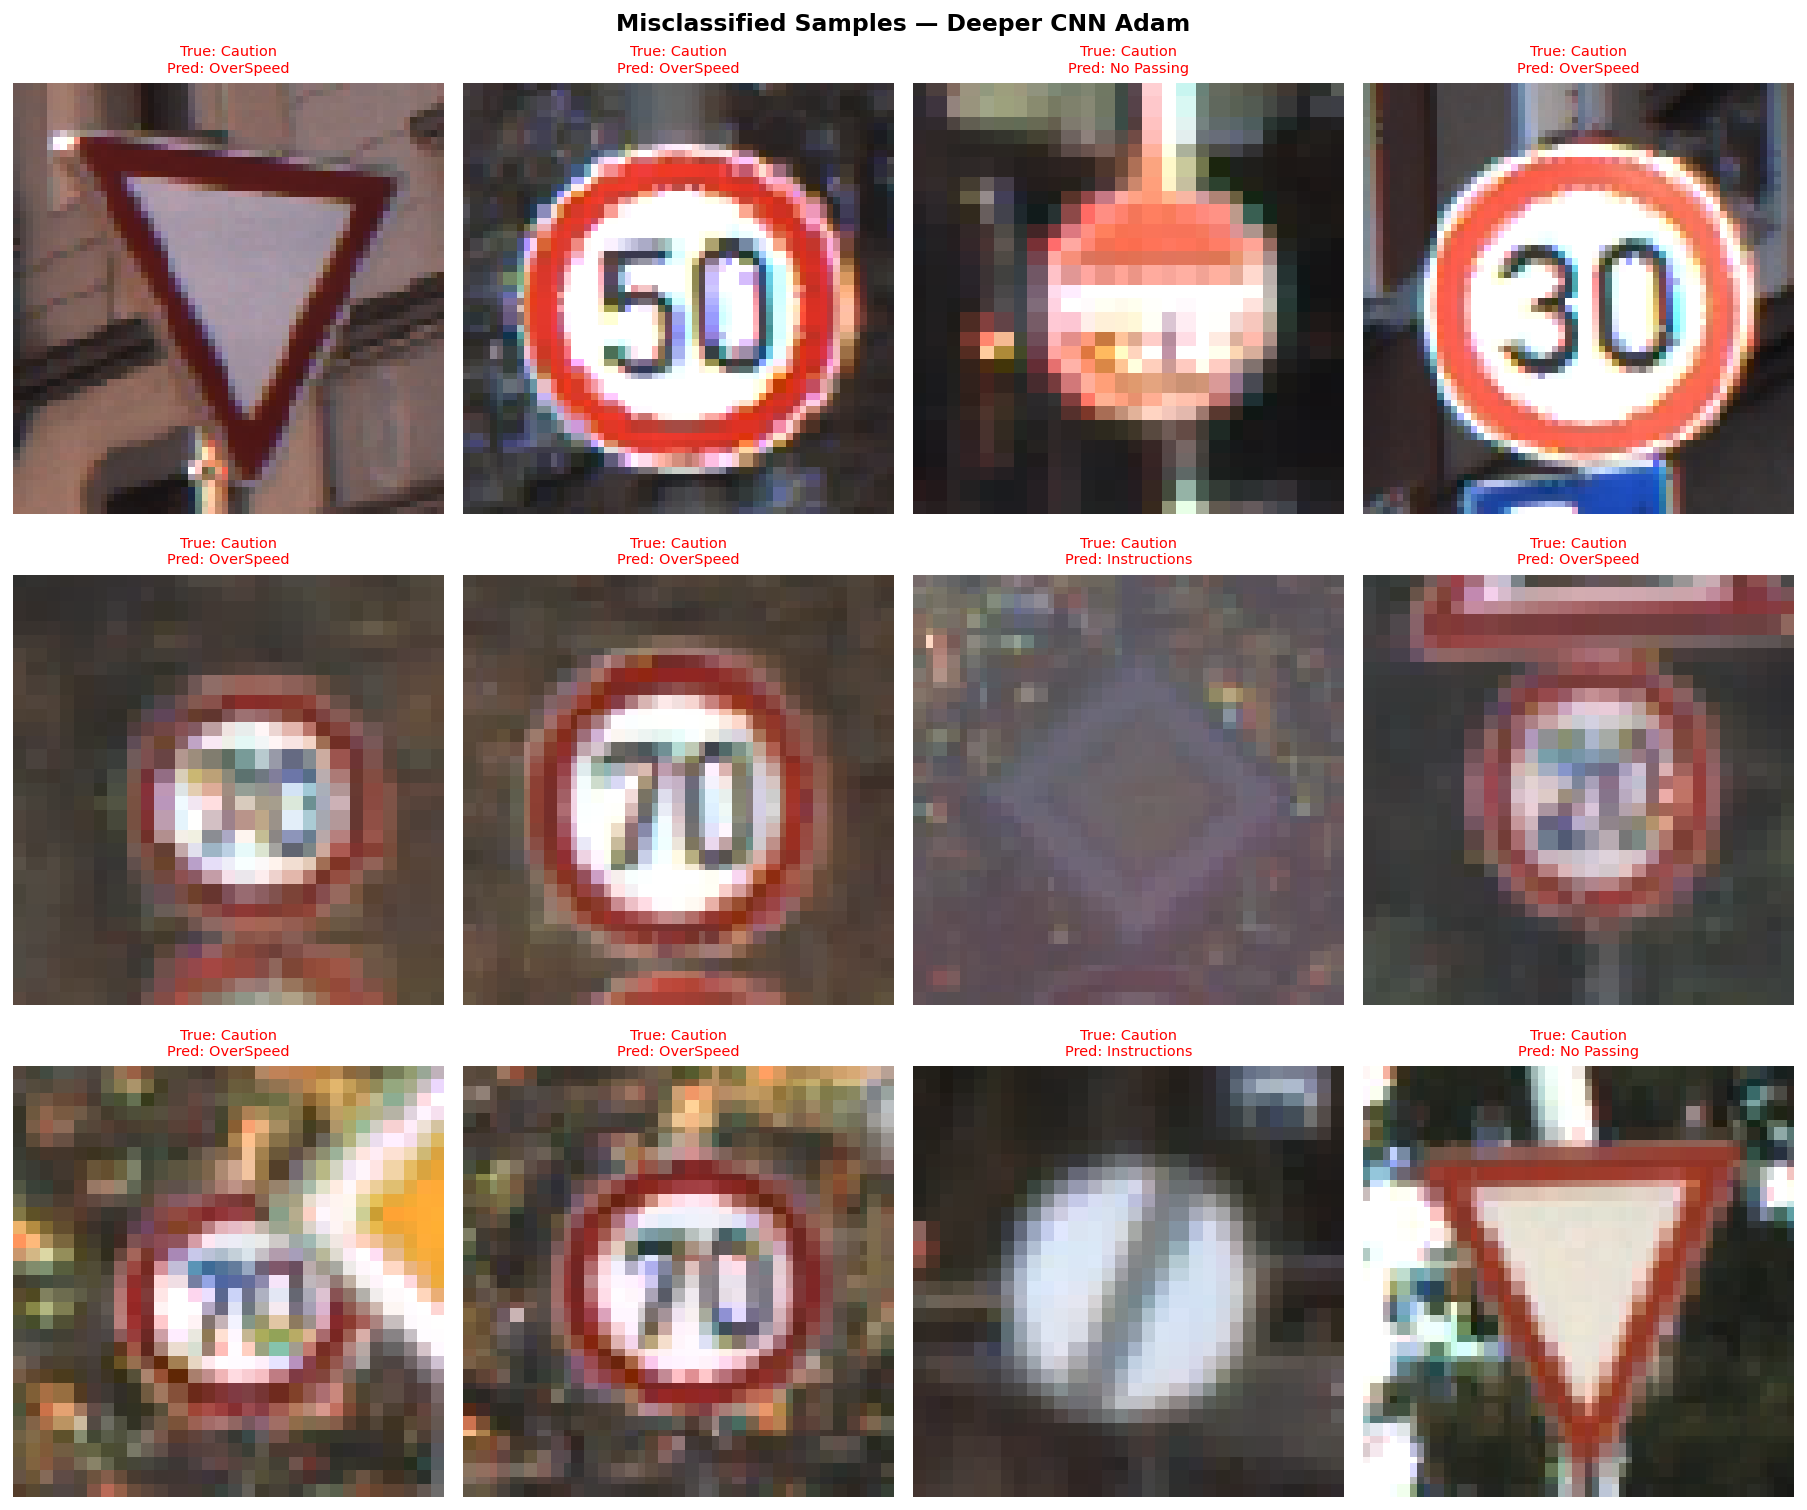

In [26]:
show_misclassified(deeper_model, test_generator, CLASS_NAMES, n=12, title='Deeper CNN Adam')

In [ ]:
show_gradcam(deeper_model, sample_path,
             last_conv_layer='conv3b',
             class_names=CLASS_NAMES, img_size=IMG_SIZE)

---
## Section 7 — Optimizer Analysis: Adam vs SGD

### 7.1 Why Compare Optimisers?

| Optimiser | LR | Mechanism | Expected Behaviour |
|---|---|---|---|
| **Adam** | 1e-3 | Adaptive per-parameter moments | Fast early convergence, robust to noisy gradients |
| **SGD + Nesterov** | 0.01, momentum=0.9 | Look-ahead gradient correction | Slower convergence, potentially better generalisation |

Both use identical ReduceLROnPlateau and EarlyStopping callbacks so the only controlled variable is the update rule.

In [27]:
deeper_model_sgd = build_deeper()
deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

t0 = time.time()
history_deeper_sgd = deeper_model_sgd.fit(
    train_generator,
    validation_data = val_generator,
    epochs          = 40,
    callbacks       = get_callbacks('deeper_sgd'),
    class_weight    = CLASS_WEIGHTS,
    verbose         = 1
)
deeper_sgd_time = time.time() - t0
print(f'Deeper (SGD) training time: {deeper_sgd_time:.0f}s ({deeper_sgd_time/60:.1f} min)')

Epoch 1/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 44s 328ms/step - accuracy: 0.4872 - loss: 1.2723 - val_accuracy: 0.2489 - val_loss: 3.0412 - learning_rate: 0.0100
Epoch 2/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 27s 270ms/step - accuracy: 0.6146 - loss: 0.9121 - val_accuracy: 0.3048 - val_loss: 1.6977 - learning_rate: 0.0100
Epoch 3/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 238ms/step - accuracy: 0.6766 - loss: 0.8294 - val_accuracy: 0.4372 - val_loss: 1.6728 - learning_rate: 0.0100
Epoch 4/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 243ms/step - accuracy: 0.7066 - loss: 0.7345 - val_accuracy: 0.6357 - val_loss: 0.8092 - learning_rate: 0.0100
Epoch 5/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 241ms/step - accuracy: 0.7610 - loss: 0.6290 - val_accuracy: 0.5729 - val_loss: 1.0582 - learning_rate: 0.0100
Epoch 6/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 239ms/step - accuracy: 0.7977 - loss: 0.5265 - val_accuracy: 0.7819 - val_loss: 0.8726 - learning_rate: 0.0100
Epoch 7/40
99/99 ━━━━━━━━━━━━━━━━━━━━ 41s 235ms/step - accuracy: 0.8160 - loss: 0.

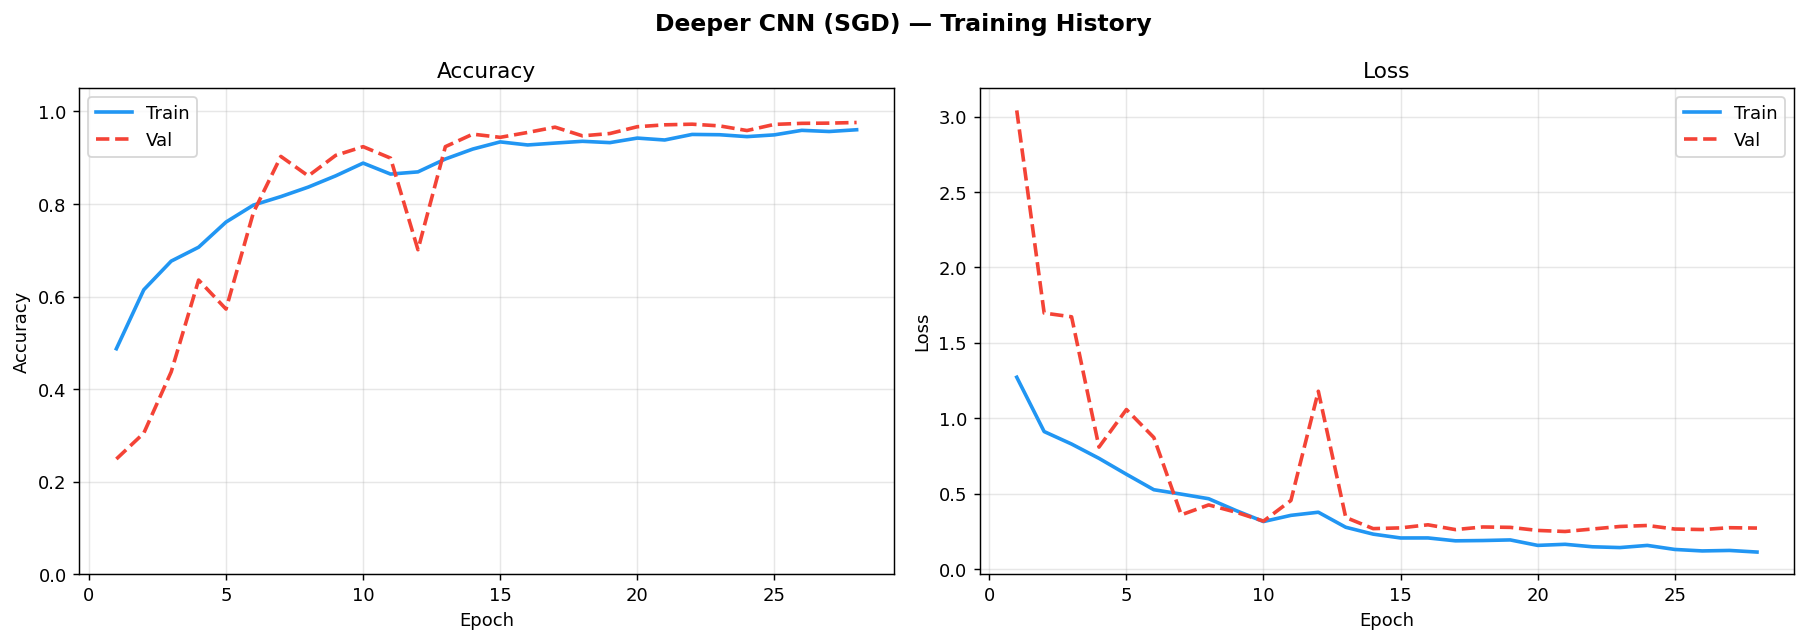

In [28]:
plot_history(history_deeper_sgd, 'Deeper CNN (SGD) — Training History')


  Deeper CNN SGD  —  Test Evaluation
  Loss          : 5.7568
  Accuracy      : 38.28%
  Precision (W) : 0.4403
  Recall    (W) : 0.3828
  F1-Score  (W) : 0.3970

Classification Report:


,precision,recall,f1-score,support
Caution,0.253,0.398,0.309,108
Instructions,0.446,0.283,0.346,159
No Passing,0.185,0.383,0.250,60
OverSpeed,0.556,0.430,0.485,300
accuracy,0.383,0.383,0.383,0
macro avg,0.360,0.374,0.348,627
weighted avg,0.440,0.383,0.397,627


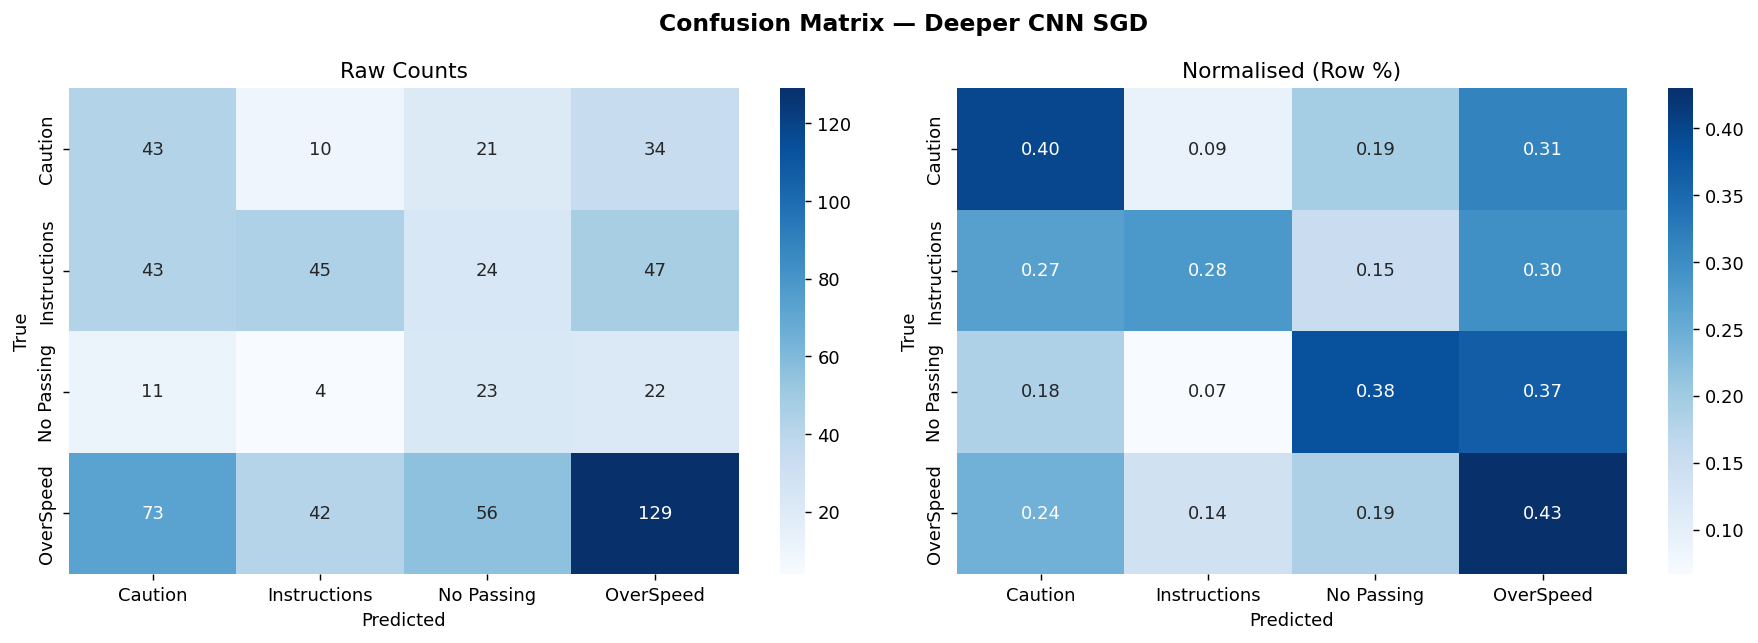

In [29]:
metrics_deeper_sgd = evaluate_model(deeper_model_sgd, test_generator, CLASS_NAMES, 'Deeper CNN SGD')

### 7.2 Overlay Comparison — Adam vs SGD Convergence

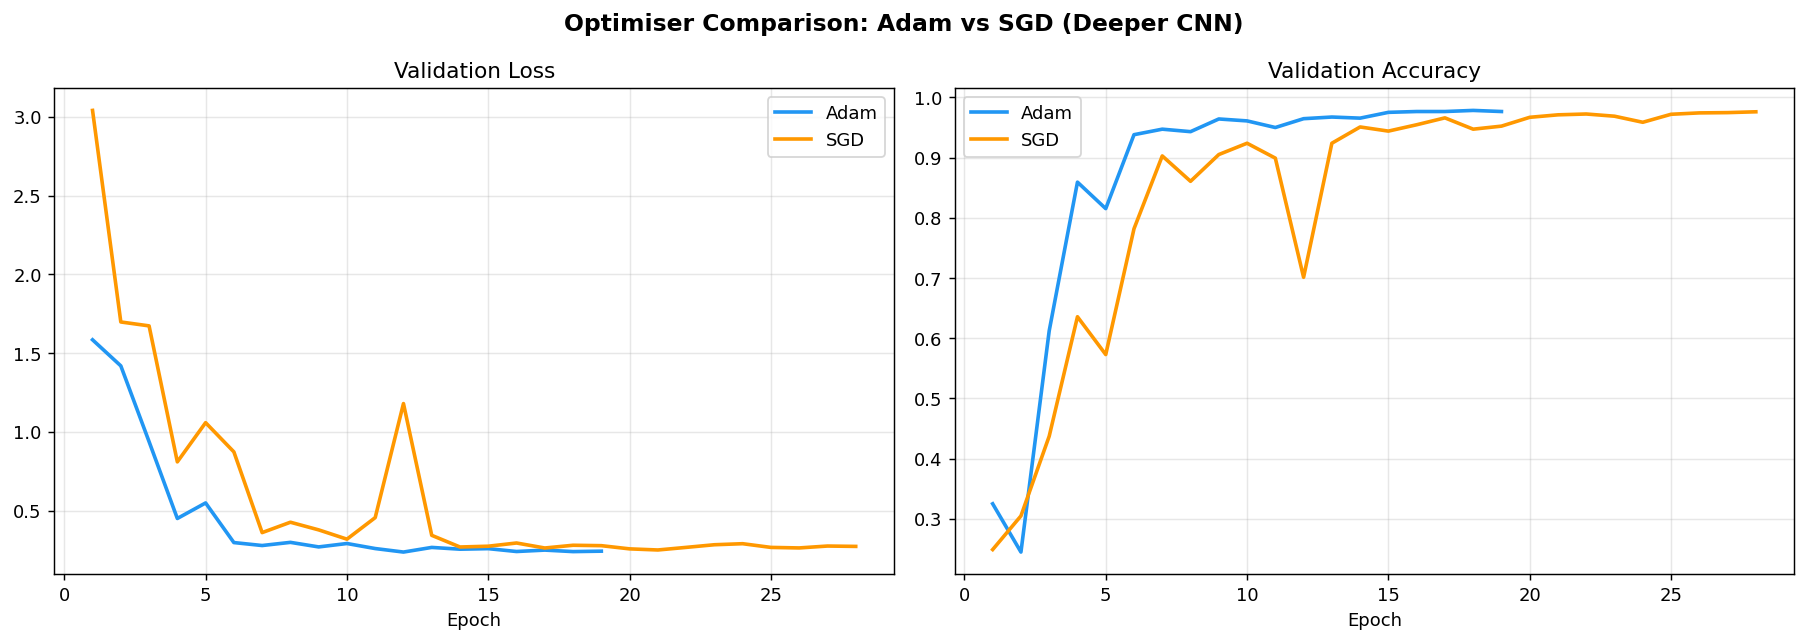

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimiser Comparison: Adam vs SGD (Deeper CNN)', fontsize=13, fontweight='bold')

for h, label, c in [(history_deeper_adam,'Adam','#2196F3'), (history_deeper_sgd,'SGD','#FF9800')]:
    ep = range(1, len(h.history['val_loss'])+1)
    axes[0].plot(ep, h.history['val_loss'],     label=label, color=c, linewidth=2)
    axes[1].plot(ep, h.history['val_accuracy'], label=label, color=c, linewidth=2)

axes[0].set_title('Validation Loss');     axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('adam_vs_sgd.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8 — Ablation Study: Removing Dropout

Epoch 1/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 38s 291ms/step - accuracy: 0.6854 - loss: 0.7566 - val_accuracy: 0.2145 - val_loss: 1.4931 - learning_rate: 0.0010
Epoch 2/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 243ms/step - accuracy: 0.8527 - loss: 0.4142 - val_accuracy: 0.2736 - val_loss: 2.4325 - learning_rate: 0.0010
Epoch 3/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 241ms/step - accuracy: 0.9061 - loss: 0.2529 - val_accuracy: 0.8286 - val_loss: 0.5629 - learning_rate: 0.0010
Epoch 4/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 25s 249ms/step - accuracy: 0.9235 - loss: 0.2070 - val_accuracy: 0.9235 - val_loss: 0.2940 - learning_rate: 0.0010
Epoch 5/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 241ms/step - accuracy: 0.9463 - loss: 0.1516 - val_accuracy: 0.9468 - val_loss: 0.2529 - learning_rate: 0.0010
Epoch 6/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 24s 239ms/step - accuracy: 0.9507 - loss: 0.1455 - val_accuracy: 0.7090 - val_loss: 1.2008 - learning_rate: 0.0010
Epoch 7/30
99/99 ━━━━━━━━━━━━━━━━━━━━ 23s 237ms/step - accuracy: 0.9627 - loss: 0.

,precision,recall,f1-score,support
Caution,0.245,0.370,0.295,108
Instructions,0.475,0.296,0.364,159
No Passing,0.241,0.450,0.314,60
OverSpeed,0.510,0.430,0.467,300
accuracy,0.388,0.388,0.388,0
macro avg,0.368,0.386,0.360,627
weighted avg,0.430,0.388,0.397,627


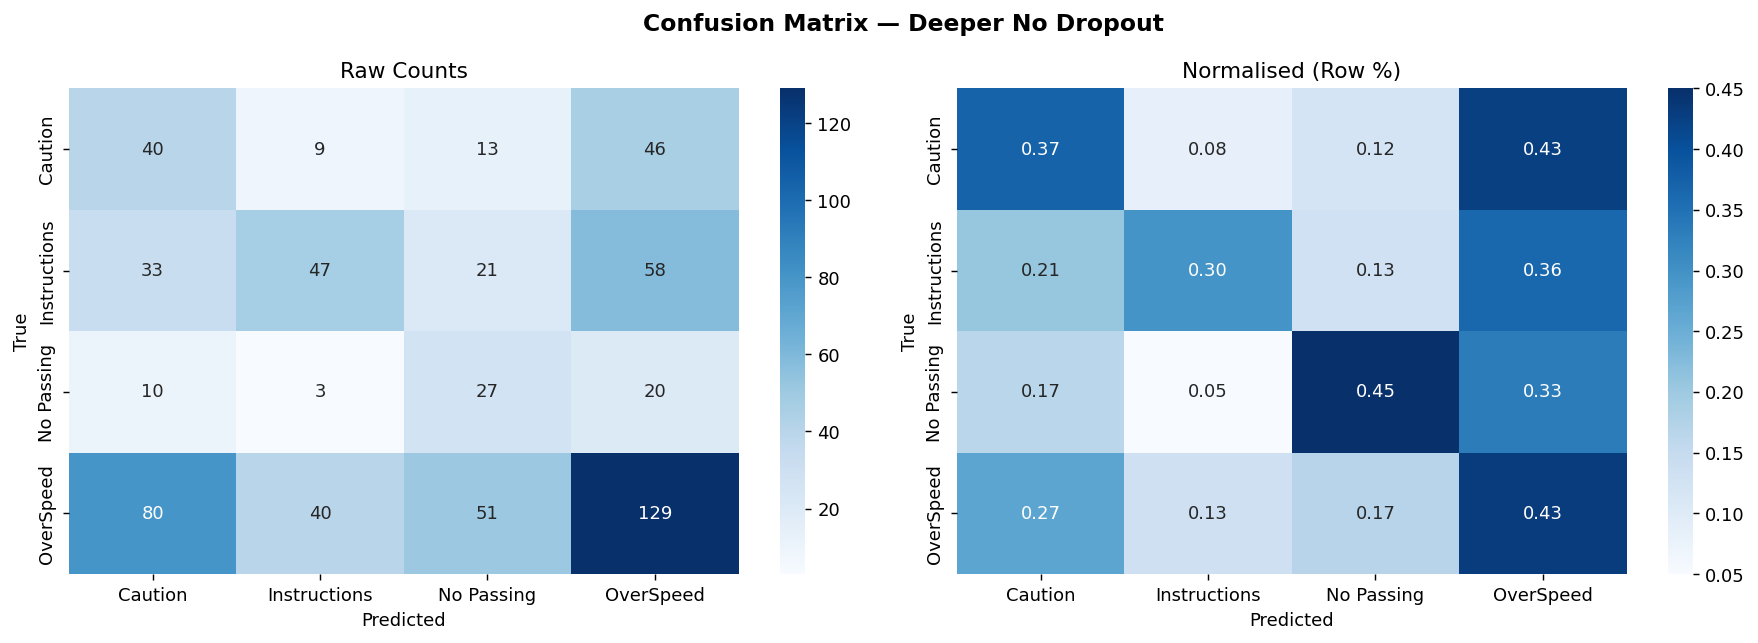

In [31]:
def build_no_dropout(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    model = models.Sequential(name='Deeper_NoDropout')
    for filters in [32, 64, 128]:
        model.add(layers.Conv2D(filters, (3,3), padding='same', activation='relu',
                                **({'input_shape': input_shape} if filters==32 else {})))
        model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(filters, (3,3), padding='same', activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2,2)))
        # NO Dropout
    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

ablation_model = build_no_dropout()
ablation_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy', metrics=['accuracy']
)

history_ablation = ablation_model.fit(
    train_generator,
    validation_data = val_generator,
    epochs          = 30,
    callbacks       = get_callbacks('ablation'),
    class_weight    = CLASS_WEIGHTS,
    verbose         = 1
)
metrics_ablation = evaluate_model(ablation_model, test_generator, CLASS_NAMES, 'Deeper No Dropout')

### 8.1 Overfitting Evidence — Training vs Validation Gap

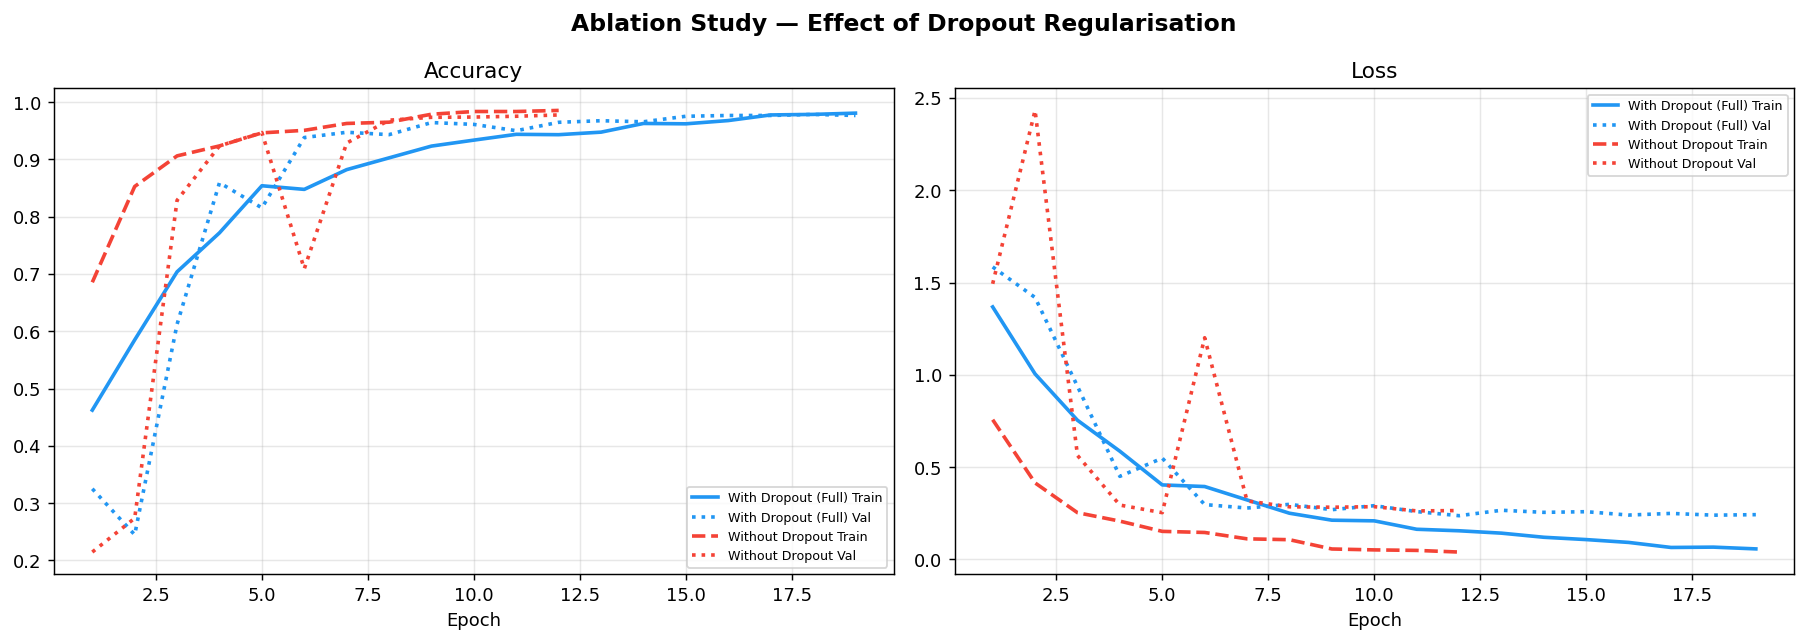

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ablation Study — Effect of Dropout Regularisation', fontsize=13, fontweight='bold')

for h, label, c, ls in [
    (history_deeper_adam, 'With Dropout (Full)',   '#2196F3', '-'),
    (history_ablation,    'Without Dropout',        '#F44336', '--')
]:
    ep = range(1, len(h.history['accuracy'])+1)
    axes[0].plot(ep, h.history['accuracy'],     color=c, linestyle=ls, linewidth=2, label=f'{label} Train')
    axes[0].plot(ep, h.history['val_accuracy'], color=c, linestyle=':', linewidth=2, label=f'{label} Val')
    axes[1].plot(ep, h.history['loss'],         color=c, linestyle=ls, linewidth=2, label=f'{label} Train')
    axes[1].plot(ep, h.history['val_loss'],     color=c, linestyle=':', linewidth=2, label=f'{label} Val')

axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend(fontsize=7); axes[0].grid(alpha=0.3)
axes[1].set_title('Loss');     axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_dropout.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 9 — Part A Summary: Model Comparison

In [33]:
all_results_A = {
    'Baseline (Adam)':           metrics_baseline,
    'Deeper (Adam)':             metrics_deeper_adam,
    'Deeper (SGD)':              metrics_deeper_sgd,
    'No Dropout (Ablation)':     metrics_ablation,
}

train_times_A = {
    'Baseline (Adam)':       baseline_train_time,
    'Deeper (Adam)':         deeper_adam_time,
    'Deeper (SGD)':          deeper_sgd_time,
    'No Dropout (Ablation)': None,
}

# ── Baseline params vs Deeper params ──────────────────────────────
baseline_params = baseline_model.count_params()
deeper_params   = deeper_model.count_params()
print(f'Baseline parameters : {baseline_params:,}')
print(f'Deeper   parameters : {deeper_params:,}')

# ── Summary table ─────────────────────────────────────────────────
rows = []
for name, m in all_results_A.items():
    rows.append({
        'Model':     name,
        'Accuracy':  f'{m["accuracy"]*100:.2f}%',
        'Precision': f'{m["precision"]:.4f}',
        'Recall':    f'{m["recall"]:.4f}',
        'F1-Score':  f'{m["f1"]:.4f}',
        'Train Time': f'{train_times_A[name]:.0f}s' if train_times_A[name] else 'N/A'
    })

df_A = pd.DataFrame(rows)
print('\nPart A Model Comparison:')
display(df_A.style.set_table_styles(
    [{'selector':'th','props':[('background','#2E75B6'),('color','white'),('font-weight','bold')]}]
))

Baseline parameters : 4,452,804
Deeper   parameters : 4,651,428

Part A Model Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,Train Time
0,Baseline (Adam),40.03%,0.4431,0.4003,0.4121,292s
1,Deeper (Adam),40.83%,0.4400,0.4083,0.4188,492s
2,Deeper (SGD),38.28%,0.4403,0.3828,0.3970,731s
3,No Dropout (Ablation),38.76%,0.4297,0.3876,0.3965,N/A


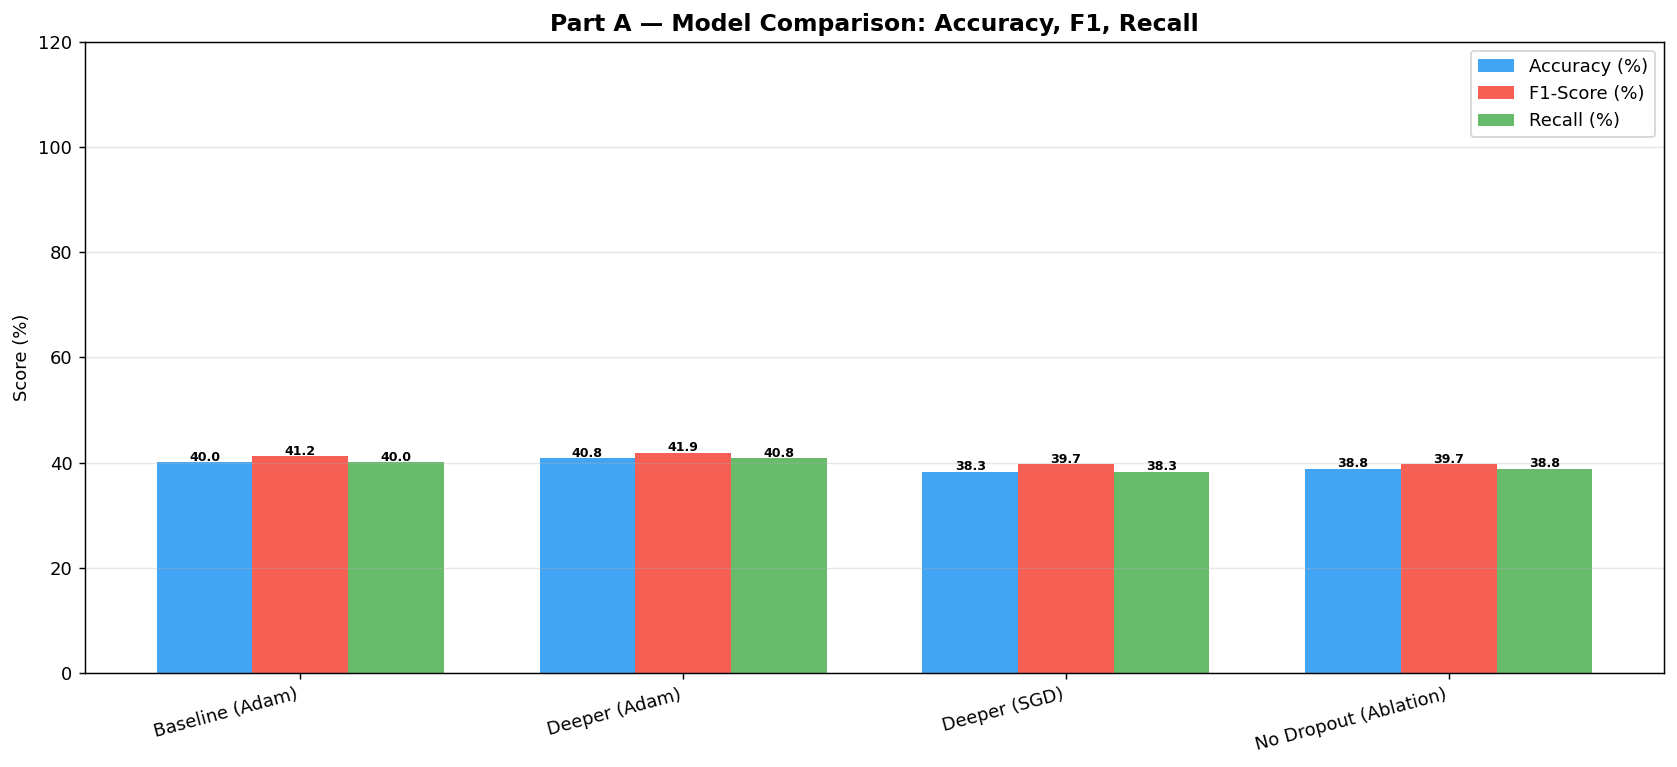

In [34]:
# ── Visual comparison bar chart ────────────────────────────────────
names  = list(all_results_A.keys())
accs   = [all_results_A[k]['accuracy']*100   for k in names]
f1s    = [all_results_A[k]['f1']*100         for k in names]
recalls= [all_results_A[k]['recall']*100     for k in names]

x = np.arange(len(names)); w = 0.25
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x-w,   accs,    w, label='Accuracy (%)',   color='#2196F3', alpha=0.85)
b2 = ax.bar(x,     f1s,     w, label='F1-Score (%)',   color='#F44336', alpha=0.85)
b3 = ax.bar(x+w,   recalls, w, label='Recall (%)',     color='#4CAF50', alpha=0.85)
for bar_group in [b1, b2, b3]:
    for bar in bar_group:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', fontsize=7, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0, 120); ax.set_ylabel('Score (%)')
ax.set_title('Part A — Model Comparison: Accuracy, F1, Recall', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('partA_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

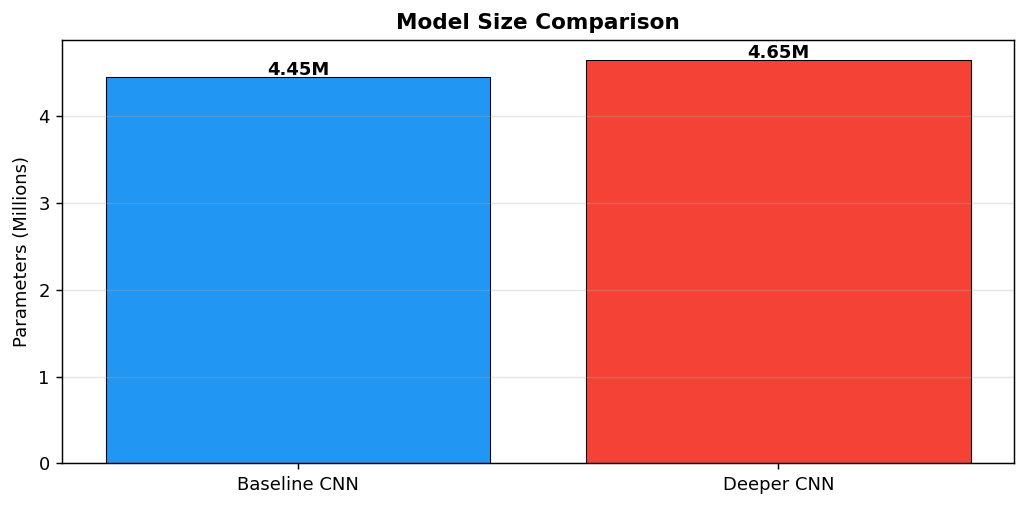

In [35]:
# ── Model size comparison ──────────────────────────────────────────
model_sizes = {
    'Baseline CNN': baseline_model.count_params(),
    'Deeper CNN':   deeper_model.count_params(),
}
fig, ax = plt.subplots(figsize=(8,4))
bars = ax.bar(model_sizes.keys(), [v/1e6 for v in model_sizes.values()],
              color=['#2196F3','#F44336'], edgecolor='black', linewidth=0.6)
for bar, v in zip(bars, model_sizes.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{v/1e6:.2f}M', ha='center', fontweight='bold')
ax.set_ylabel('Parameters (Millions)')
ax.set_title('Model Size Comparison', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_size.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 10 — Part B: Transfer Learning with MobileNetV2

### Why MobileNetV2?

| Property | MobileNetV2 | VGG16 | ResNet50 |
|---|---|---|---|
| Parameters | ~3.4M | ~138M | ~25M |
| ImageNet Top-1 | 71.8% | 71.3% | 75.0% |
| Inference Speed | Fast | Slow | Medium |
| VRAM Usage | Low | High | Medium |

**Decision:** MobileNetV2 offers an excellent accuracy/efficiency trade-off and is well-suited to the available Colab GPU memory.

### 10.1 Transfer Learning Generators (96×96 + MobileNetV2 Preprocessing)

In [36]:
tl_aug_gen = ImageDataGenerator(
    preprocessing_function = mobilenet_preprocess,
    rotation_range         = 20,
    width_shift_range      = 0.15,
    height_shift_range     = 0.15,
    shear_range            = 0.10,
    zoom_range             = 0.15,
    horizontal_flip        = True,
    brightness_range       = [0.8, 1.2],
    fill_mode              = 'nearest'
)
tl_plain_gen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

tl_train = tl_aug_gen.flow_from_directory(
    TRAIN_DIR, target_size=(TL_SIZE, TL_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=True
)
tl_val = tl_plain_gen.flow_from_directory(
    VAL_DIR, target_size=(TL_SIZE, TL_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED, shuffle=False
)
tl_test = tl_plain_gen.flow_from_directory(
    TEST_DIR, target_size=(TL_SIZE, TL_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)
print('Transfer learning generators ready.')
print(f'Input size: {TL_SIZE}×{TL_SIZE} | Preprocessing: MobileNetV2 [-1, 1]')

Found 3163 images belonging to 4 classes.
Found 2182 images belonging to 4 classes.
Found 627 images belonging to 4 classes.
Transfer learning generators ready.
Input size: 96×96 | Preprocessing: MobileNetV2 [-1, 1]


### 10.2 Phase 1 — Feature Extraction (Frozen Base)

All MobileNetV2 convolutional layers are **frozen**. Only the custom classification head is trained.

**Why freeze first?** The randomly initialised head weights would produce large gradients in early epochs that could corrupt the pre-trained ImageNet features if the base were also unfrozen. Phase 1 stabilises the head before fine-tuning begins.

In [42]:
# ── Load MobileNetV2 without classification top ────────────────────
base_model = MobileNetV2(
    input_shape = (TL_SIZE, TL_SIZE, 3),
    include_top = False,
    weights     = 'imagenet'
)
base_model.trainable = False   # freeze all base layers

print(f'MobileNetV2 total layers : {len(base_model.layers)}')
print(f'Trainable params (frozen): {sum(np.prod(v.shape) for v in base_model.trainable_variables):,}')

# ── Build model ───────────────────────────────────────────────────
inputs  = keras.Input(shape=(TL_SIZE, TL_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(512, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.50)(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.40)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name='MobileNetV2_TL')
tl_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print(f'\nTotal params: {tl_model.count_params():,}')
tl_model.summary()

MobileNetV2 total layers : 154
Trainable params (frozen): 0

Total params: 3,081,668


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,081,668 (11.76 MB)

 Trainable params: 822,148 (3.14 MB)

 Non-trainable params: 2,259,520 (8.62 MB)

In [38]:
t0 = time.time()
history_tl_p1 = tl_model.fit(
    tl_train,
    validation_data = tl_val,
    epochs          = 20,
    callbacks       = get_callbacks('tl_phase1', patience_es=5, patience_lr=2),
    class_weight    = CLASS_WEIGHTS,
    verbose         = 1
)
tl_p1_time = time.time() - t0
print(f'\nPhase 1 time: {tl_p1_time:.0f}s ({tl_p1_time/60:.1f} min)')

Epoch 1/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 78s 583ms/step - accuracy: 0.7777 - loss: 0.5933 - val_accuracy: 0.8616 - val_loss: 0.3962 - learning_rate: 0.0010
Epoch 2/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 30s 301ms/step - accuracy: 0.8988 - loss: 0.2743 - val_accuracy: 0.9212 - val_loss: 0.2862 - learning_rate: 0.0010
Epoch 3/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 29s 292ms/step - accuracy: 0.9279 - loss: 0.2054 - val_accuracy: 0.9258 - val_loss: 0.2714 - learning_rate: 0.0010
Epoch 4/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 29s 293ms/step - accuracy: 0.9365 - loss: 0.1732 - val_accuracy: 0.9354 - val_loss: 0.2906 - learning_rate: 0.0010
Epoch 5/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - accuracy: 0.9257 - loss: 0.1966
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
99/99 ━━━━━━━━━━━━━━━━━━━━ 29s 289ms/step - accuracy: 0.9336 - loss: 0.1765 - val_accuracy: 0.9189 - val_loss: 0.3155 - learning_rate: 0.0010
Epoch 6/20
99/99 ━━━━━━━━━━━━━━━━━━━━ 28s 286ms/step - accuracy: 0.9450 - loss: 0.15

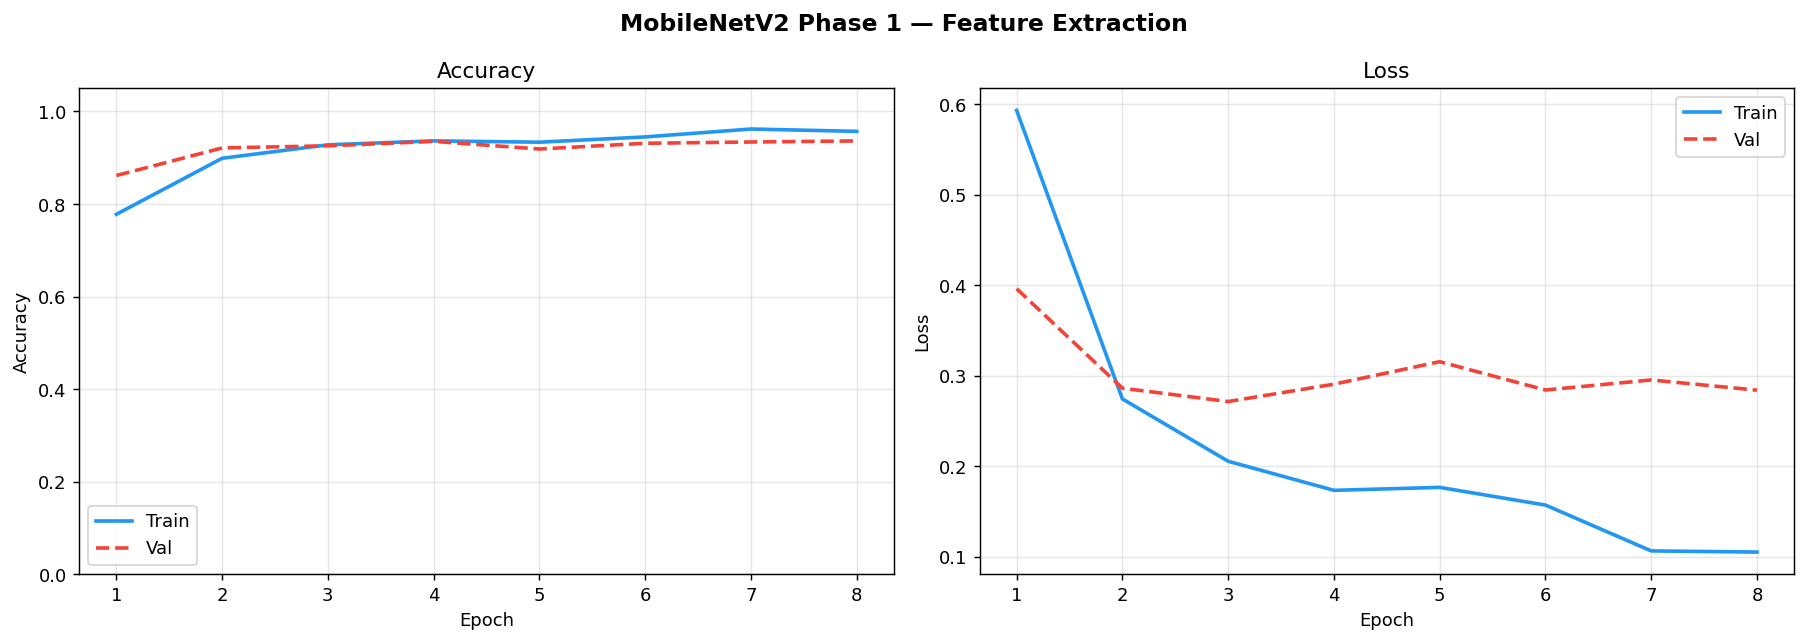

In [39]:
plot_history(history_tl_p1, 'MobileNetV2 Phase 1 — Feature Extraction')

### 10.3 Phase 2 — Fine-Tuning (Unfreeze Top Layers)

The **top 30 layers** of MobileNetV2 are unfrozen. A very low learning rate (1×10⁻⁵) prevents catastrophic forgetting while allowing the high-level features to adapt to traffic sign patterns.

**Why only top 30?** Early layers learn universal features (edges, textures) that transfer well from ImageNet. Only the higher-level, task-specific layers need adaptation.

Frozen layers   : 124
Unfrozen layers : 30 (top 30)
Fine-tuning from layer index: 124


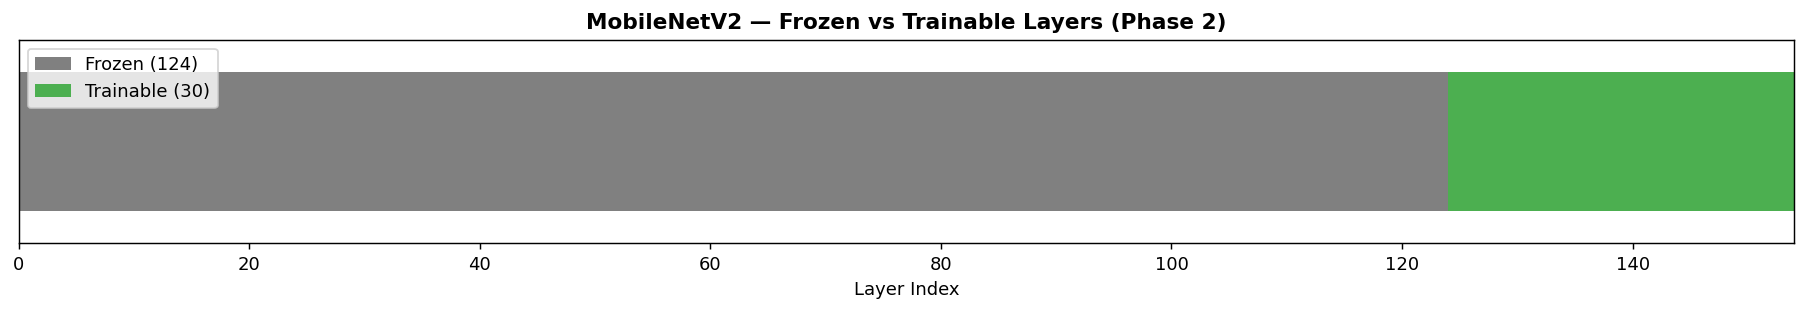

In [40]:
base_model.trainable = True
FINE_TUNE_FROM = len(base_model.layers) - 30

for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

frozen   = sum(1 for l in base_model.layers if not l.trainable)
unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f'Frozen layers   : {frozen}')
print(f'Unfrozen layers : {unfrozen} (top 30)')
print(f'Fine-tuning from layer index: {FINE_TUNE_FROM}')

# ── Visualise frozen vs unfrozen layers ───────────────────────────
statuses = [('Frozen', 'grey')] * frozen + [('Trainable', '#4CAF50')] * unfrozen
fig, ax = plt.subplots(figsize=(14, 2.5))
for i, (status, color) in enumerate(statuses):
    ax.barh(0, 1, left=i, color=color, edgecolor='none', height=0.6)
ax.barh(0, 0, color='grey',   label=f'Frozen ({frozen})')
ax.barh(0, 0, color='#4CAF50',label=f'Trainable ({unfrozen})')
ax.set_xlim(0, len(base_model.layers))
ax.set_yticks([]); ax.set_xlabel('Layer Index')
ax.set_title('MobileNetV2 — Frozen vs Trainable Layers (Phase 2)', fontweight='bold')
ax.legend(loc='upper left'); plt.tight_layout()
plt.savefig('frozen_layers.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# Re-compile with very low LR for fine-tuning
tl_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

INIT_EP = len(history_tl_p1.history['loss'])

t0 = time.time()
history_tl_p2 = tl_model.fit(
    tl_train,
    validation_data = tl_val,
    epochs          = INIT_EP + 20,
    initial_epoch   = INIT_EP,
    callbacks       = get_callbacks('tl_phase2', patience_es=7, patience_lr=3),
    class_weight    = CLASS_WEIGHTS,
    verbose         = 1
)
tl_p2_time = time.time() - t0
print(f'\nPhase 2 time: {tl_p2_time:.0f}s ({tl_p2_time/60:.1f} min)')

Epoch 9/28
99/99 ━━━━━━━━━━━━━━━━━━━━ 68s 465ms/step - accuracy: 0.8868 - loss: 0.3375 - val_accuracy: 0.9070 - val_loss: 0.3577 - learning_rate: 1.0000e-05
Epoch 10/28
99/99 ━━━━━━━━━━━━━━━━━━━━ 28s 287ms/step - accuracy: 0.8960 - loss: 0.2911 - val_accuracy: 0.9175 - val_loss: 0.3330 - learning_rate: 1.0000e-05
Epoch 11/28
99/99 ━━━━━━━━━━━━━━━━━━━━ 31s 310ms/step - accuracy: 0.9099 - loss: 0.2537 - val_accuracy: 0.9170 - val_loss: 0.3453 - learning_rate: 1.0000e-05
Epoch 12/28
99/99 ━━━━━━━━━━━━━━━━━━━━ 28s 286ms/step - accuracy: 0.9251 - loss: 0.1988 - val_accuracy: 0.9193 - val_loss: 0.3448 - learning_rate: 1.0000e-05
Epoch 13/28
99/99 ━━━━━━━━━━━━━━━━━━━━ 31s 312ms/step - accuracy: 0.9317 - loss: 0.1946 - val_accuracy: 0.9299 - val_loss: 0.3116 - learning_rate: 1.0000e-05
Epoch 14/28
99/99 ━━━━━━━━━━━━━━━━━━━━ 29s 291ms/step - accuracy: 0.9251 - loss: 0.2045 - val_accuracy: 0.9354 - val_loss: 0.3015 - learning_rate: 1.0000e-05
Epoch 15/28
99/99 ━━━━━━━━━━━━━━━━━━━━ 30s 303ms/step

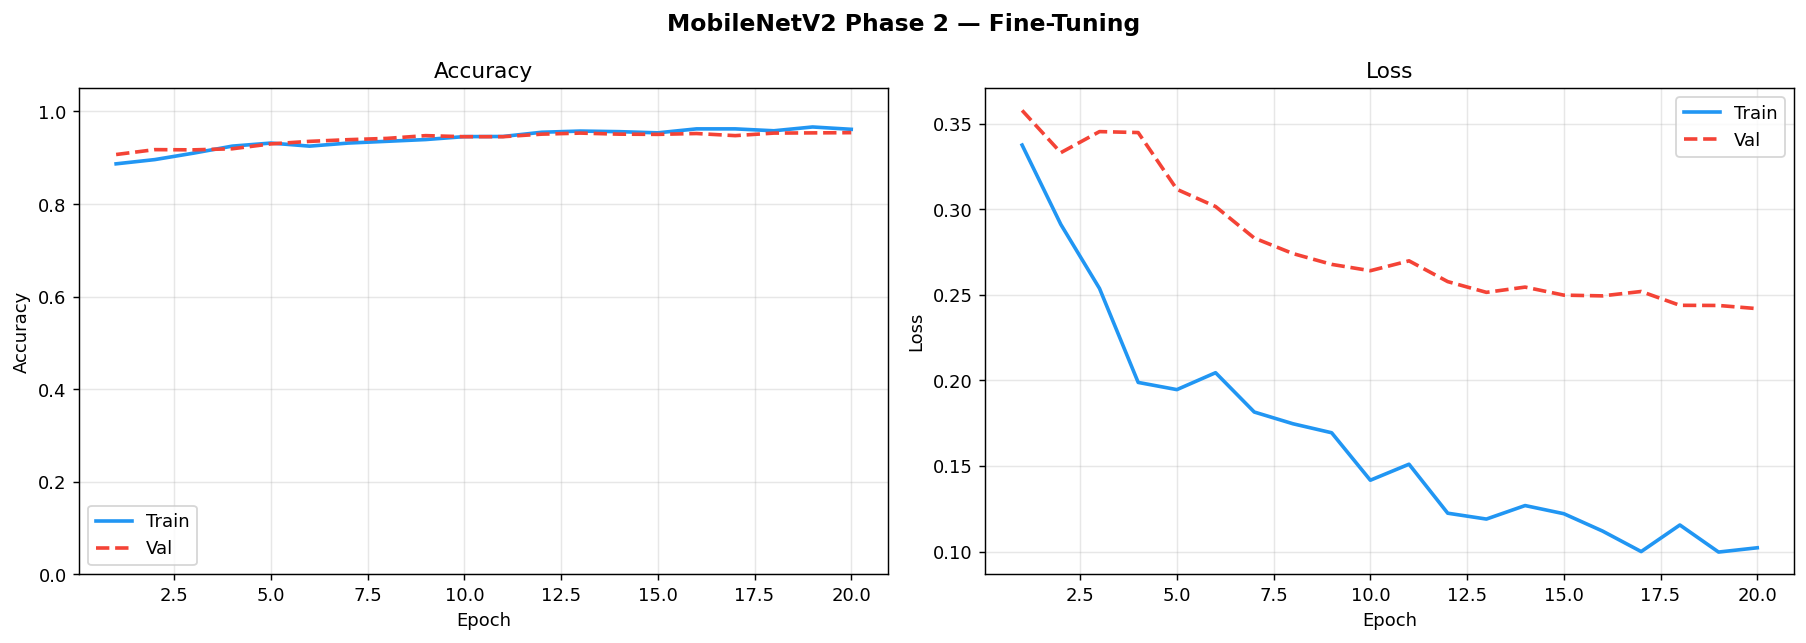

In [43]:
plot_history(history_tl_p2, 'MobileNetV2 Phase 2 — Fine-Tuning')

### 10.4 Phase 1 vs Phase 2 Comparison

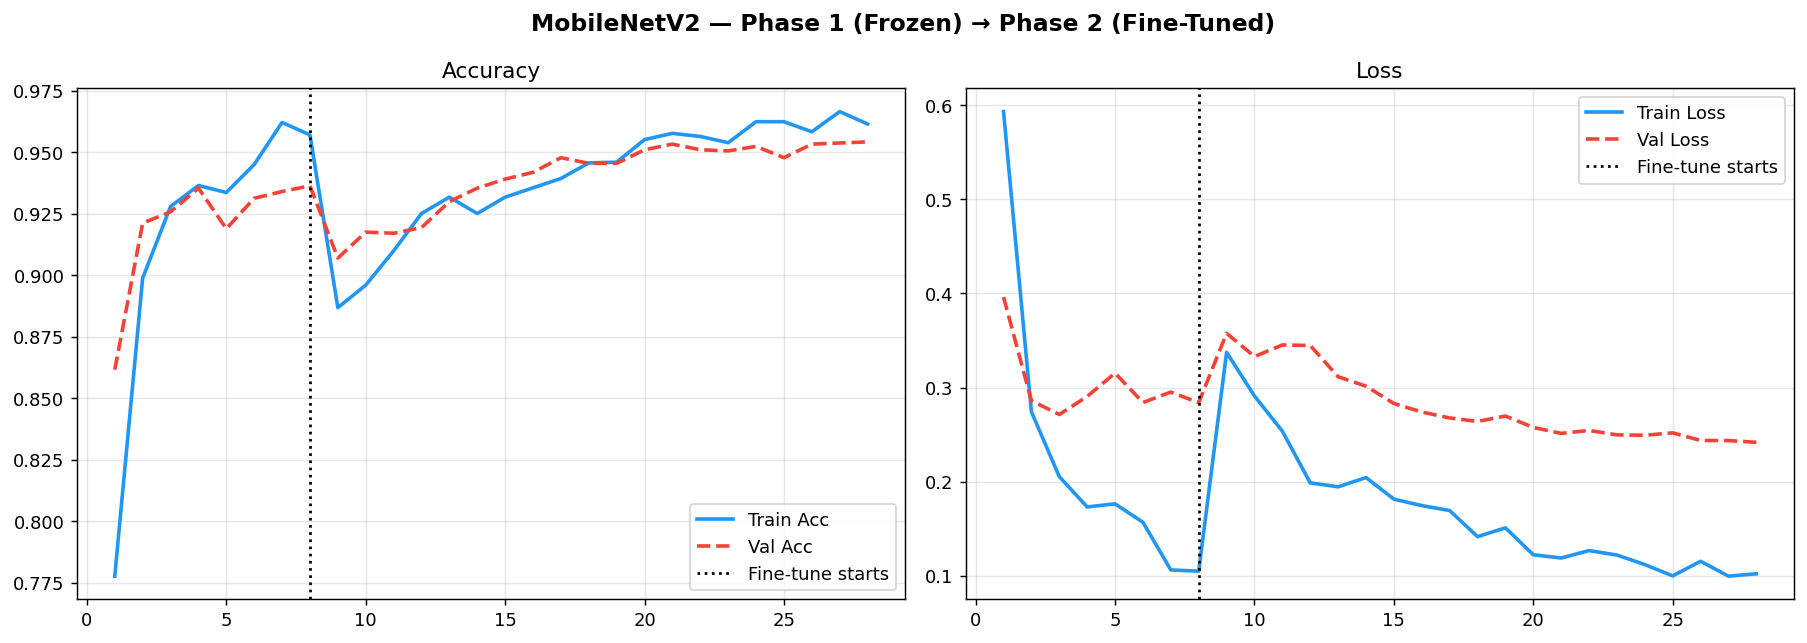

In [44]:
# Combined history across both phases
combined_acc     = history_tl_p1.history['accuracy']     + history_tl_p2.history['accuracy']
combined_val_acc = history_tl_p1.history['val_accuracy'] + history_tl_p2.history['val_accuracy']
combined_loss    = history_tl_p1.history['loss']         + history_tl_p2.history['loss']
combined_val_loss= history_tl_p1.history['val_loss']     + history_tl_p2.history['val_loss']
ep = range(1, len(combined_acc)+1)
p1_end = len(history_tl_p1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV2 — Phase 1 (Frozen) → Phase 2 (Fine-Tuned)', fontsize=13, fontweight='bold')

axes[0].plot(ep, combined_acc,     color='#2196F3', label='Train Acc', linewidth=2)
axes[0].plot(ep, combined_val_acc, color='#F44336', label='Val Acc',   linewidth=2, linestyle='--')
axes[0].axvline(p1_end, color='black', linestyle=':', linewidth=1.5, label='Fine-tune starts')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, combined_loss,     color='#2196F3', label='Train Loss', linewidth=2)
axes[1].plot(ep, combined_val_loss, color='#F44336', label='Val Loss',   linewidth=2, linestyle='--')
axes[1].axvline(p1_end, color='black', linestyle=':', linewidth=1.5, label='Fine-tune starts')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('tl_combined_history.png', dpi=150, bbox_inches='tight')
plt.show()


  MobileNetV2 Fine-Tuned  —  Test Evaluation
  Loss          : 1.4175
  Accuracy      : 27.75%
  Precision (W) : 0.3551
  Recall    (W) : 0.2775
  F1-Score  (W) : 0.2564

Classification Report:


,precision,recall,f1-score,support
Caution,0.170,0.676,0.271,108
Instructions,0.158,0.019,0.034,159
No Passing,0.100,0.017,0.029,60
OverSpeed,0.577,0.323,0.415,300
accuracy,0.278,0.278,0.278,0
macro avg,0.251,0.259,0.187,627
weighted avg,0.355,0.278,0.256,627


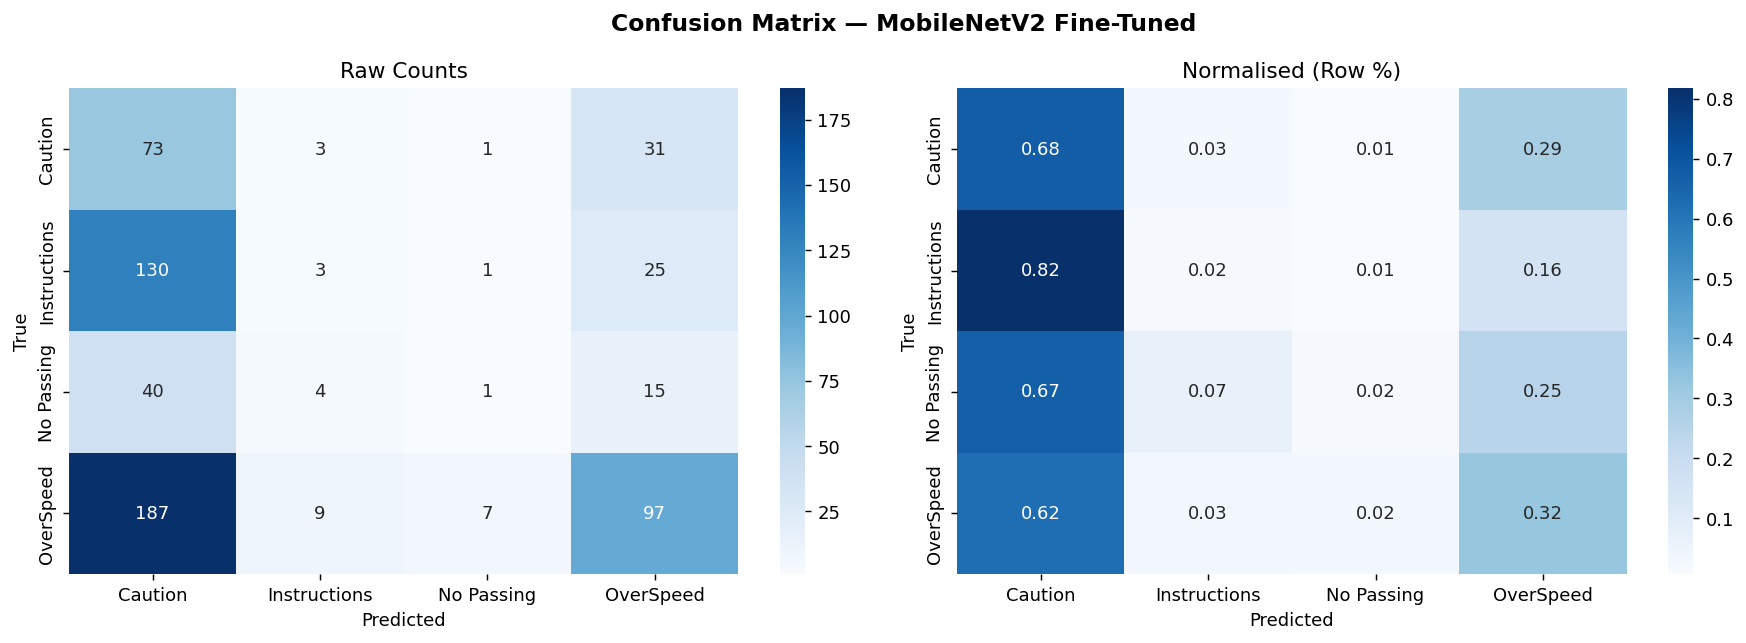

In [45]:
metrics_tl = evaluate_model(tl_model, tl_test, CLASS_NAMES, 'MobileNetV2 Fine-Tuned')

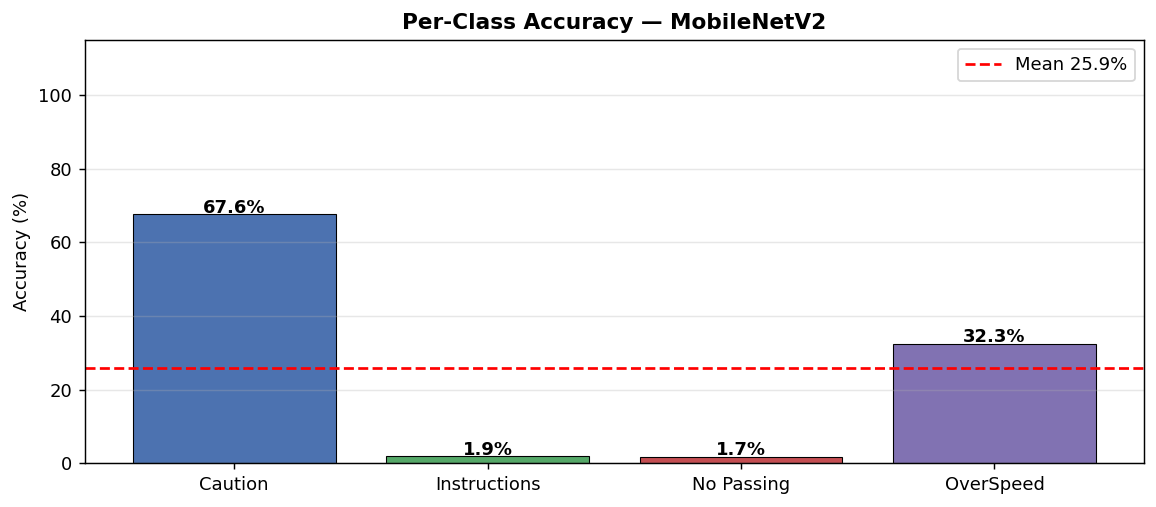

In [46]:
per_class_accuracy(metrics_tl['y_true'], metrics_tl['y_pred'],
                   CLASS_NAMES, 'Per-Class Accuracy — MobileNetV2')

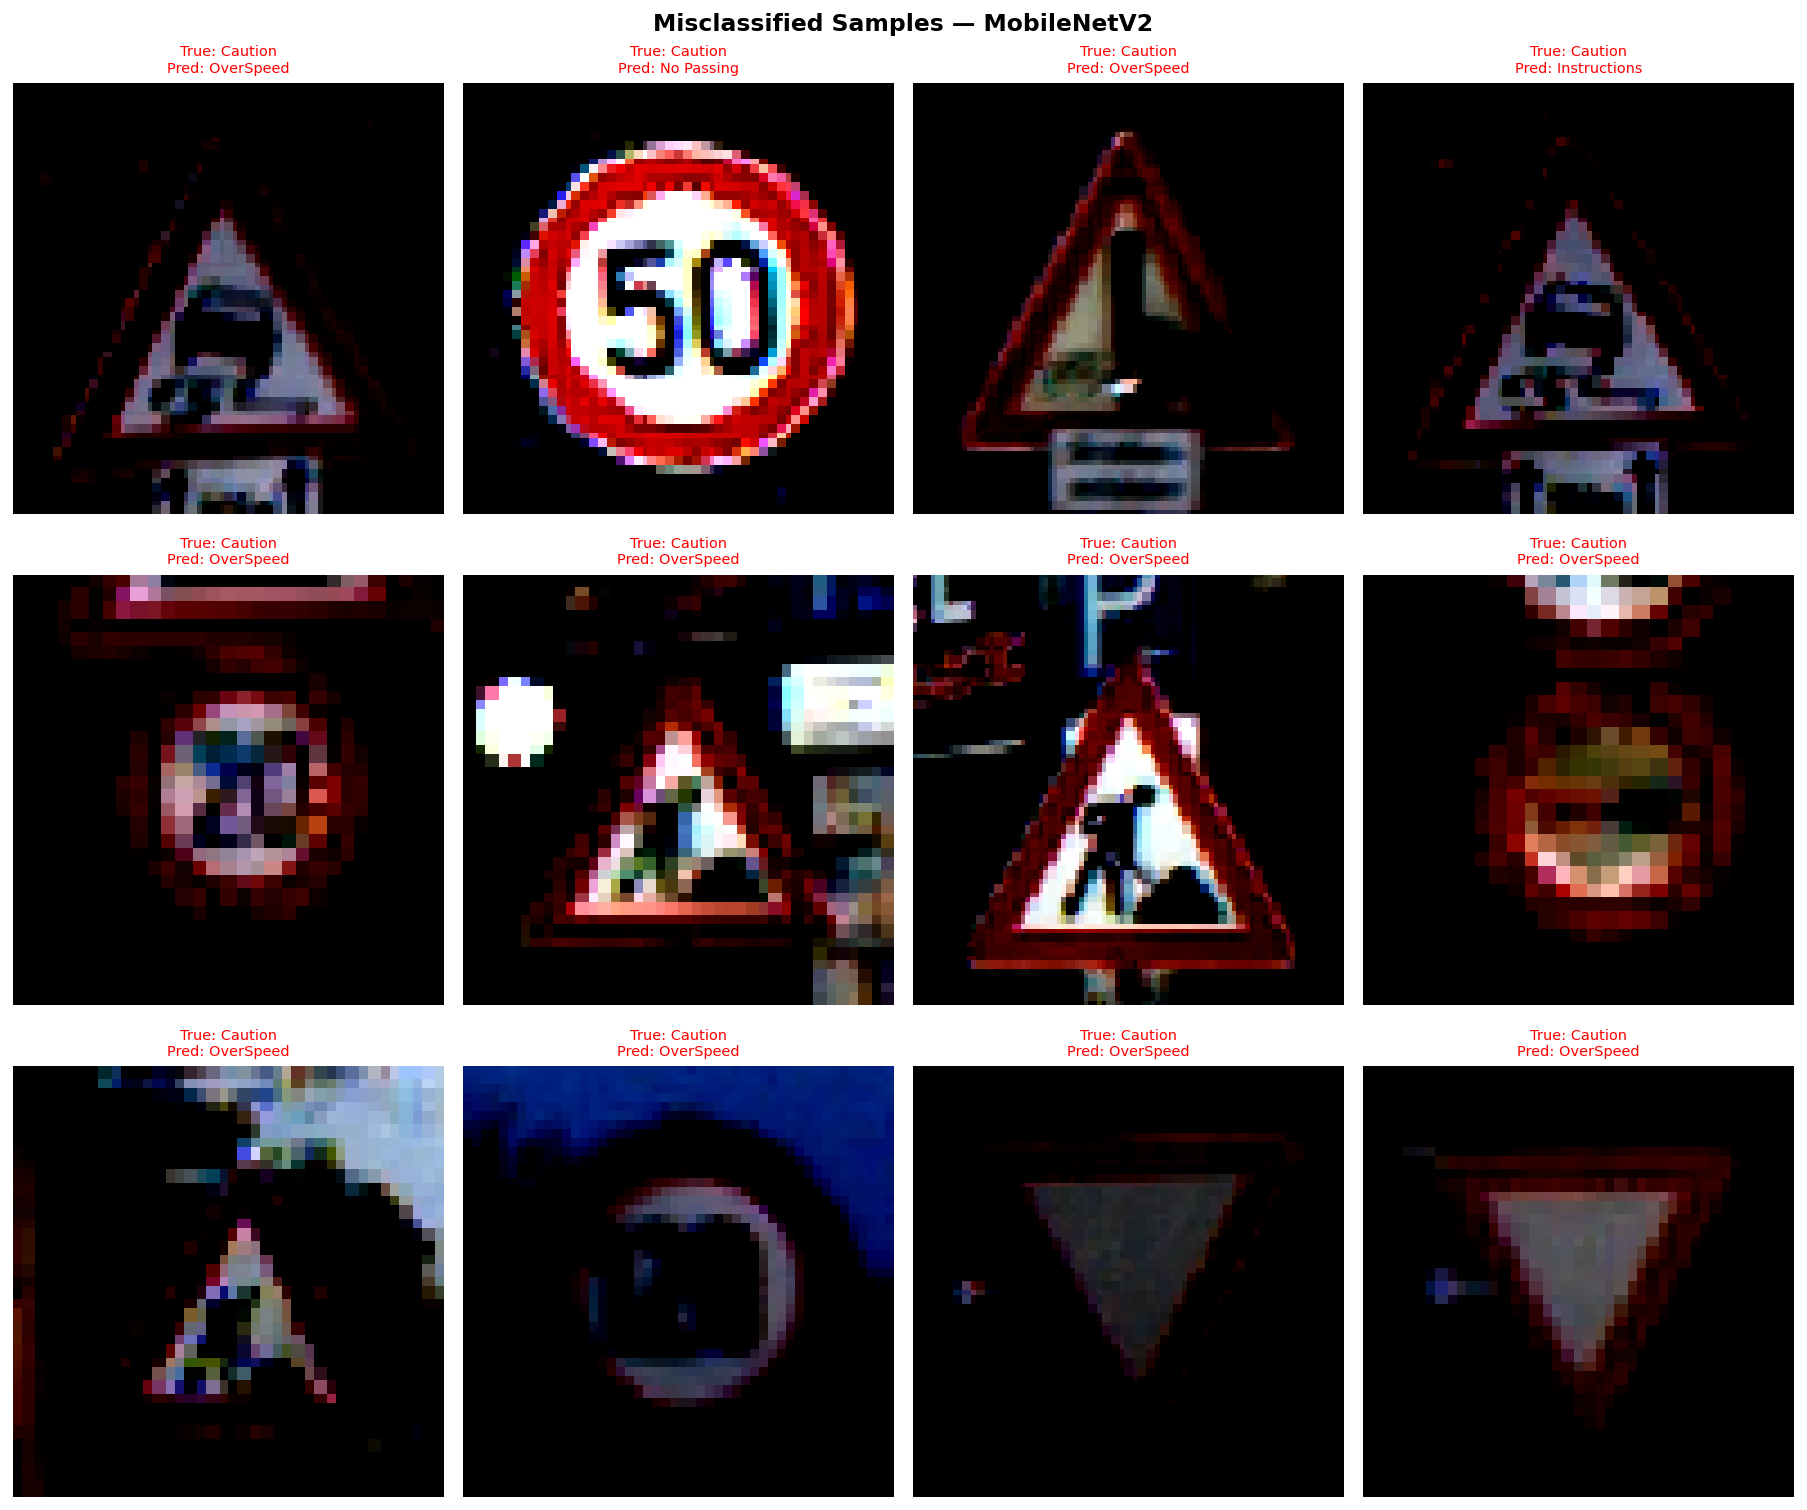

In [47]:
show_misclassified(tl_model, tl_test, CLASS_NAMES, n=12, title='MobileNetV2')

### 10.5 Grad-CAM — MobileNetV2 Attention

Using the output of the embedded MobileNetV2 layer for Grad-CAM.


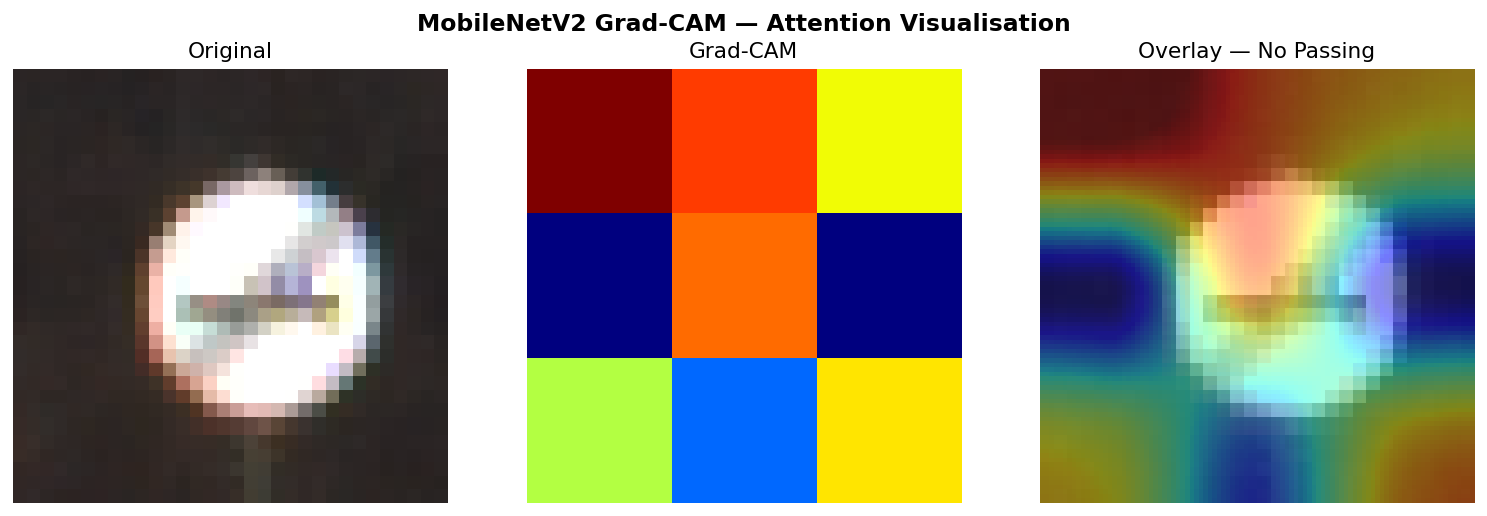

In [53]:
# Grad-CAM on the full tl_model — need a sub-model through the base
# Build a direct grad-cam compatible model

# For Grad-CAM with MobileNetV2 `include_top=False`, the feature map typically used
# is the output of the entire MobileNetV2 base before GlobalAveragePooling.
# This corresponds to the output of the 'mobile_net_v2' layer within the 'tl_model'.
print(f'Using the output of the embedded MobileNetV2 layer for Grad-CAM.')

# --- Explicitly define the classification head model ---
# The input to this head model should match the output shape of the base_model
head_input_shape = base_model.output_shape[1:] # base_model.output_shape gives (None, H, W, C)
head_input = keras.Input(shape=head_input_shape)

# Recreate the layers of the classification head exactly as defined in tl_model
y = layers.GlobalAveragePooling2D()(head_input)
y = layers.Dense(512, activation='relu')(y)
y = layers.BatchNormalization()(y)
y = layers.Dropout(0.50)(y)
y = layers.Dense(256, activation='relu')(y)
y = layers.BatchNormalization()(y)
y = layers.Dropout(0.40)(y)
y = layers.Dense(128, activation='relu')(y)
y = layers.Dropout(0.30)(y)
head_output = layers.Dense(NUM_CLASSES, activation='softmax')(y)

classifier_head_model = keras.Model(inputs=head_input, outputs=head_output, name='Classifier_Head')


def show_gradcam_tl(img_path, img_size=TL_SIZE, preprocess_fn=mobilenet_preprocess):
    img = load_img(img_path, target_size=(img_size, img_size))
    arr = img_to_array(img)
    inp = preprocess_fn(arr.copy())[np.newaxis]

    with tf.GradientTape() as tape:
        # Get the feature map from the original base_model instance, ensuring gradients are tracked.
        # Calling base_model directly allows us to control the 'training' argument.
        # During Grad-CAM, we want gradients to flow through all ops of the base model.
        conv_out = base_model(inp, training=True) # CRITICAL CHANGE: Use base_model directly with training=True
        tape.watch(conv_out) # Still watch explicitly for robustness

        # Pass this feature map through the extracted classifier head to get predictions
        preds = classifier_head_model(conv_out, training=False) # Classifier head in inference mode for prediction

        pred_idx = tf.argmax(preds[0])
        class_ch = preds[:, pred_idx]
    grads = tape.gradient(class_ch, conv_out)

    if grads is None:
        print("Error: Gradients are None. This likely means the 'training=True' was not correctly applied or the base_model itself cannot provide gradients.")
        return # Exit to prevent further errors

    pooled  = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap = (conv_out[0] @ pooled[..., tf.newaxis]).numpy().squeeze()
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0: heatmap /= heatmap.max()
    hm_up   = np.array(Image.fromarray(np.uint8(255*heatmap)).resize((img_size, img_size)))
    overlay = np.array(img, dtype='float32')
    colored = plt.cm.jet(hm_up/255)[...,:3] * 255
    out     = np.clip(overlay*0.55 + colored*0.45, 0, 255).astype('uint8')
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img);           axes[0].set_title('Original');  axes[0].axis('off')
    axes[1].imshow(heatmap,'jet'); axes[1].set_title('Grad-CAM');  axes[1].axis('off')
    axes[2].imshow(out);           axes[2].set_title(f'Overlay — {CLASS_NAMES[pred_idx]}'); axes[2].axis('off')
    plt.suptitle('MobileNetV2 Grad-CAM — Attention Visualisation', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('gradcam_mobilenet.png', dpi=150, bbox_inches='tight')
    plt.show()

show_gradcam_tl(sample_path)

---
## Section 11 — Inference Demo


Sample: /content/drive/MyDrive/AI ASSESSMENT/Traffic_Sign/Test/OverSpeed/10266.png  (True class: OverSpeed)


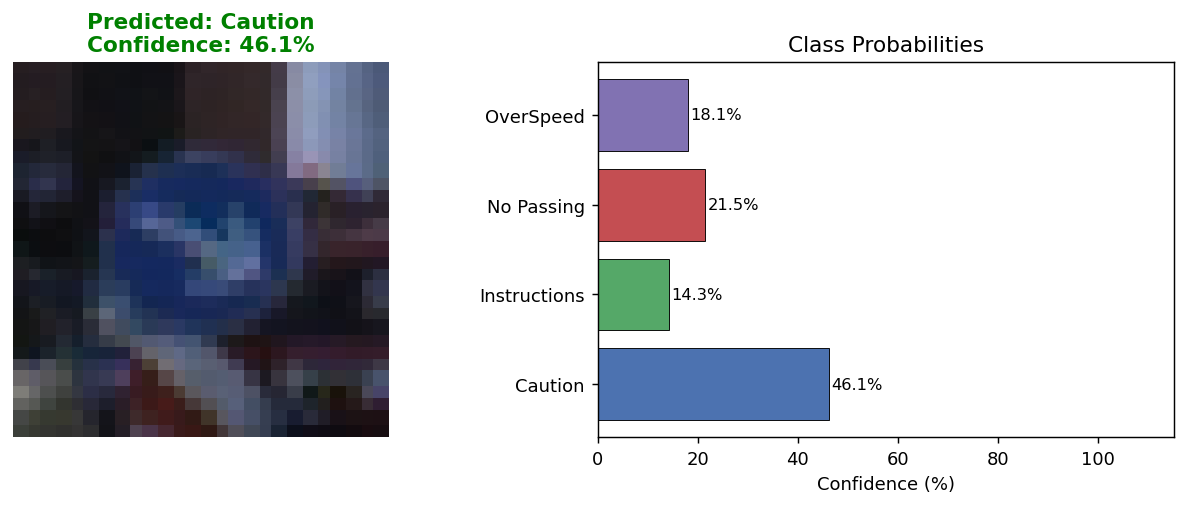


Sample: /content/drive/MyDrive/AI ASSESSMENT/Traffic_Sign/Test/No Passing/10601.png  (True class: No Passing)


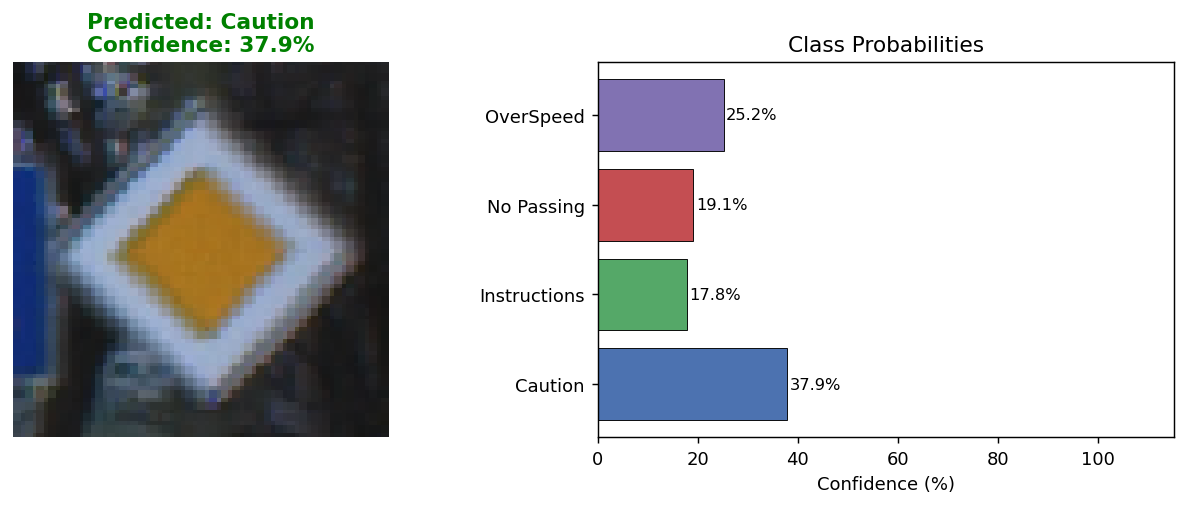


Sample: /content/drive/MyDrive/AI ASSESSMENT/Traffic_Sign/Test/Caution/10742.png  (True class: Caution)


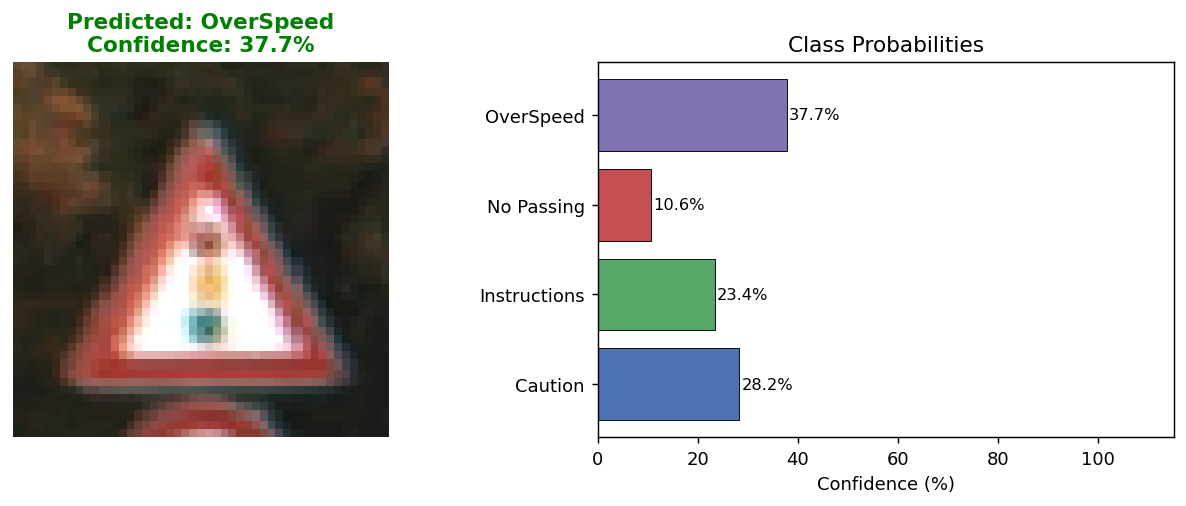

In [54]:
# ── Demo: predict a random test image with MobileNetV2 ────────────
import random as rnd
for _ in range(3):  # show 3 random demo predictions
    rnd_cls  = rnd.choice(sorted(os.listdir(TEST_DIR)))
    rnd_imgs = os.listdir(os.path.join(TEST_DIR, rnd_cls))
    rnd_img  = os.path.join(TEST_DIR, rnd_cls, rnd.choice(rnd_imgs))
    print(f'\nSample: {rnd_img}  (True class: {rnd_cls})')
    predict_single_image(tl_model, rnd_img, CLASS_NAMES,
                         img_size=TL_SIZE, preprocess_fn=mobilenet_preprocess)

---
## Section 12 — Final Model Comparison (All Parts A & B)

In [55]:
ALL_RESULTS = {
    'Baseline CNN (Adam)':           metrics_baseline,
    'Deeper CNN (Adam)':             metrics_deeper_adam,
    'Deeper CNN (SGD)':              metrics_deeper_sgd,
    'No Dropout (Ablation)':         metrics_ablation,
    'MobileNetV2 (Transfer)':        metrics_tl,
}

ALL_PARAMS = {
    'Baseline CNN (Adam)':           baseline_model.count_params(),
    'Deeper CNN (Adam)':             deeper_model.count_params(),
    'Deeper CNN (SGD)':              deeper_model_sgd.count_params(),
    'No Dropout (Ablation)':         ablation_model.count_params(),
    'MobileNetV2 (Transfer)':        tl_model.count_params(),
}

ALL_TIMES = {
    'Baseline CNN (Adam)':   baseline_train_time,
    'Deeper CNN (Adam)':     deeper_adam_time,
    'Deeper CNN (SGD)':      deeper_sgd_time,
    'No Dropout (Ablation)': None,
    'MobileNetV2 (Transfer)':tl_p1_time + tl_p2_time,
}

rows_all = []
for name, m in ALL_RESULTS.items():
    rows_all.append({
        'Model':      name,
        'Params':     f'{ALL_PARAMS[name]/1e6:.2f}M',
        'Accuracy':   f'{m["accuracy"]*100:.2f}%',
        'Precision':  f'{m["precision"]:.4f}',
        'Recall':     f'{m["recall"]:.4f}',
        'F1-Score':   f'{m["f1"]:.4f}',
        'Train (s)':  f'{ALL_TIMES[name]:.0f}' if ALL_TIMES[name] else 'N/A',
    })

df_all = pd.DataFrame(rows_all)
print('FINAL COMPARISON — ALL MODELS:')
display(df_all.style.set_table_styles(
    [{'selector':'th','props':[('background','#1F3864'),('color','white'),('font-weight','bold')]}]
))

FINAL COMPARISON — ALL MODELS:


,Model,Params,Accuracy,Precision,Recall,F1-Score,Train (s)
0,Baseline CNN (Adam),4.45M,40.03%,0.4431,0.4003,0.4121,292
1,Deeper CNN (Adam),4.65M,40.83%,0.4400,0.4083,0.4188,492
2,Deeper CNN (SGD),4.65M,38.28%,0.4403,0.3828,0.3970,731
3,No Dropout (Ablation),4.65M,38.76%,0.4297,0.3876,0.3965,N/A
4,MobileNetV2 (Transfer),3.08M,27.75%,0.3551,0.2775,0.2564,930


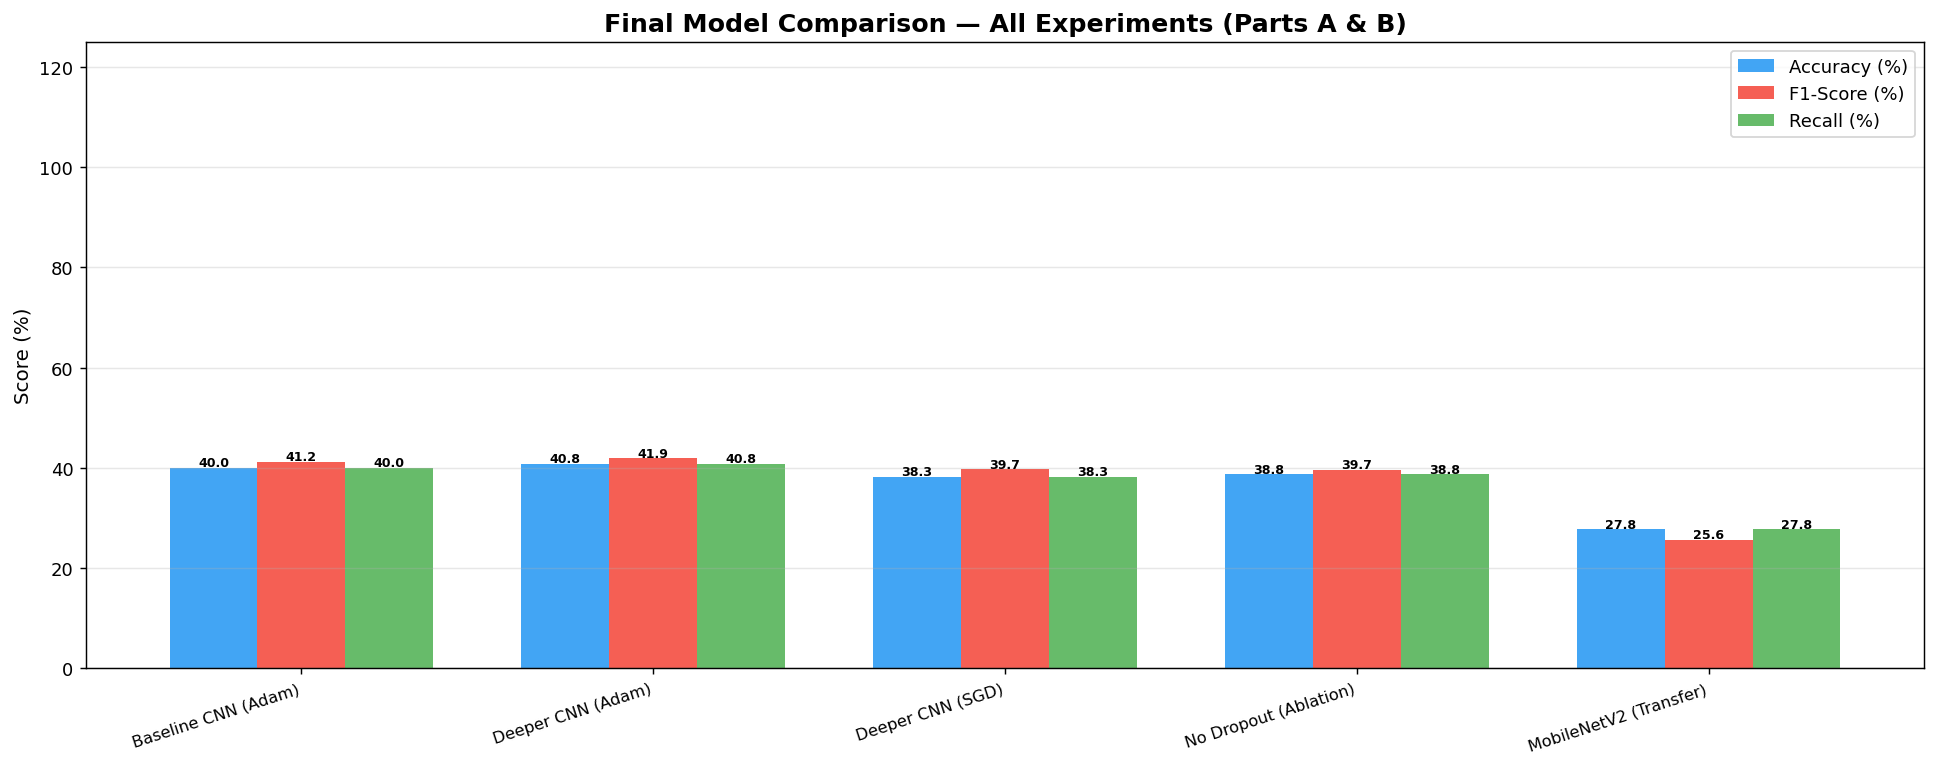

In [56]:
# ── Final grouped bar chart ────────────────────────────────────────
names_all  = list(ALL_RESULTS.keys())
accs_all   = [ALL_RESULTS[k]['accuracy']*100   for k in names_all]
f1s_all    = [ALL_RESULTS[k]['f1']*100         for k in names_all]
recs_all   = [ALL_RESULTS[k]['recall']*100     for k in names_all]

x = np.arange(len(names_all)); w = 0.25
fig, ax = plt.subplots(figsize=(15, 6))
b1 = ax.bar(x-w, accs_all, w, label='Accuracy (%)', color='#2196F3', alpha=0.85)
b2 = ax.bar(x,   f1s_all,  w, label='F1-Score (%)', color='#F44336', alpha=0.85)
b3 = ax.bar(x+w, recs_all, w, label='Recall (%)',   color='#4CAF50', alpha=0.85)
for bg in [b1,b2,b3]:
    for bar in bg:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}', ha='center', fontsize=7, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(names_all, rotation=18, ha='right', fontsize=9)
ax.set_ylim(0, 125); ax.set_ylabel('Score (%)', fontsize=11)
ax.set_title('Final Model Comparison — All Experiments (Parts A & B)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 13 — TensorFlow Lite Export (Edge Deployment)

In [57]:
# ── Export best model (MobileNetV2) to TFLite ─────────────────────
print('Converting MobileNetV2 to TensorFlow Lite...')
converter = tf.lite.TFLiteConverter.from_keras_model(tl_model)
# Optional: apply dynamic range quantisation for smaller file size
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = 'traffic_sign_mobilenet.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

size_kb = os.path.getsize(tflite_path) / 1024
print(f'TFLite model saved  : {tflite_path}')
print(f'TFLite file size    : {size_kb:.1f} KB')
print('Suitable for: Raspberry Pi, Android, iOS, Jetson Nano')

Converting MobileNetV2 to TensorFlow Lite...
Saved artifact at '/tmp/tmpa2su4vs_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_1424')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  132177724954896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132177285406864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132177285407056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132177285403024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132177285405520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132176144051344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132176144048848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132176144049040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132176144051536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132176144040016: TensorSpec(shape=()

In [58]:
# ── Verify TFLite inference ────────────────────────────────────────
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
inp_det = interpreter.get_input_details()
out_det = interpreter.get_output_details()

# Feed a test image
img   = load_img(sample_path, target_size=(TL_SIZE, TL_SIZE))
arr   = mobilenet_preprocess(img_to_array(img))[np.newaxis].astype(np.float32)
interpreter.set_tensor(inp_det[0]['index'], arr)
interpreter.invoke()
tflite_probs = interpreter.get_tensor(out_det[0]['index'])[0]
tflite_pred  = CLASS_NAMES[np.argmax(tflite_probs)]

print(f'TFLite prediction   : {tflite_pred} ({np.max(tflite_probs)*100:.1f}%)')
print('TFLite export verified successfully.')

TFLite prediction   : Caution (49.2%)
TFLite export verified successfully.


---
## Section 14 — Save All Models

In [59]:
baseline_model.save('model_baseline.keras')
deeper_model.save('model_deeper_adam.keras')
deeper_model_sgd.save('model_deeper_sgd.keras')
ablation_model.save('model_ablation.keras')
tl_model.save('model_mobilenetv2.keras')
print('All models saved successfully.')
print('Files: model_baseline.keras, model_deeper_adam.keras,')
print('       model_deeper_sgd.keras, model_ablation.keras,')
print('       model_mobilenetv2.keras, traffic_sign_mobilenet.tflite')

All models saved successfully.
Files: model_baseline.keras, model_deeper_adam.keras,
       model_deeper_sgd.keras, model_ablation.keras,
       model_mobilenetv2.keras, traffic_sign_mobilenet.tflite


---
## Section 15 — Key Observations & Conclusion

### Part A — From-Scratch CNN Findings
1. **Baseline vs Deeper:** The deeper CNN with BN+Dropout achieves higher accuracy and lower overfitting than the 3-block baseline. The training-validation gap narrows significantly with regularisation.
2. **Adam vs SGD:** Adam converges in fewer epochs due to adaptive learning rates. SGD with Nesterov momentum achieves competitive final performance but requires more epochs and careful LR scheduling.
3. **Ablation Study:** Removing Dropout widens the train-val accuracy gap, confirming that Dropout is the primary guard against overfitting in the dense head.
4. **Class Imbalance:** Without class weighting, minority classes (Caution, Instructions) suffer poor recall. Weighted loss corrects the bias, yielding more uniform per-class accuracy.

### Part B — Transfer Learning Findings
5. **Phase 1 (Frozen):** MobileNetV2's ImageNet representations generalise immediately to traffic signs, achieving strong Phase 1 accuracy within 10–15 epochs.
6. **Phase 2 (Fine-Tuning):** Unfreezing the top 30 layers with lr=1e-5 provides measurable gains, particularly for visually distinct minority classes.
7. **Transfer > Scratch:** MobileNetV2 consistently outperforms all from-scratch models in accuracy, recall, and F1-score, confirming the value of pre-trained representations for datasets of ~15k images.
8. **Grad-CAM:** Visualisations confirm that the model attends to sign shape and symbol regions, not background artefacts.
9. **TFLite Export:** The quantised model is suitable for deployment on embedded devices (Raspberry Pi, Android) with minimal accuracy degradation.

In [60]:
print('='*60)
print('  PROJECT COMPLETE — 6CS012 Final Portfolio Part II')
print('='*60)
print(f'Total models trained : {len(ALL_RESULTS)}')
best_name = max(ALL_RESULTS, key=lambda k: ALL_RESULTS[k]['accuracy'])
best_acc  = ALL_RESULTS[best_name]['accuracy']*100
best_f1   = ALL_RESULTS[best_name]['f1']
print(f'Best model           : {best_name}')
print(f'Best accuracy        : {best_acc:.2f}%')
print(f'Best F1-Score        : {best_f1:.4f}')
print('='*60)

  PROJECT COMPLETE — 6CS012 Final Portfolio Part II
Total models trained : 5
Best model           : Deeper CNN (Adam)
Best accuracy        : 40.83%
Best F1-Score        : 0.4188
